# Анализ данных о продажах компьютерных игр

1. Цель проводимого исследоваиня состоит в анализе данных и проверке ряда гипотез необходимых для обеспечения поддержки развития бизнеса по продаже компьютерных игр интернет-магазина "Стримчик", включая определение профиля потребителя и пользовательских предпочтений для рекламных кампаний.
2. Задачами настоящего исследования яляются
- детальная проработка предоставленных данных о динмике выпуска и продаж игр, о зависимости продаж от жанра или платформы игр, влияние отзывов на продажи
- проверка гипотез и оценка вреоятности действий и событий, которые позволят бизнесу вырасти

**План исследования:**
1. Обзор данных
2. Подготовка данных к исследованию
3. Анализ данных
    - анализ динамики выпуска
    - анализ динамики продаж
    - зависимость объема продаж от платформы
    - определение наиболее перспеективных платформ
    - анализ продаж в разрезе платформ
    - влияние отзывов критиков и пользователей на продажи
    - жанровые предпочтения пользователей
4. Анализ пользовательских предпочтений по регионам
5. Проверка гипотез
    - гипотеза №1 - средние пользовательские рейтинги платформ Xbox One и PC одинаковые
    - гипотеза №2 - средние пользовательские рейтинги жанров Action и Sports разные

## Обзор данных

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.stats import norm
from scipy.stats import binom
from math import factorial
from math import sqrt
import numpy as np

**Загрузим файл с данными о пользователях**

In [5]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')

In [7]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [10]:
data.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

**Описание данных**

- Name — название игры - 16713 записей, пропущена 2 записи, тип данных - текст
- Platform — платформа - 16715 записей, пропуски данных отсутствуют, тип данных - текст
- Year_of_Release — год выпуска - 16446 записей, пропущено 269 значений, тип данных - вещественное число
- Genre — жанр игры - 16713 записей, пропущена 2 записи, тип данных - текст
- NA_sales — продажи в Северной Америке (миллионы проданных копий) - 16715 записей, пропуски данных отсутствуют, тип данных - вещественное число
- EU_sales — продажи в Европе (миллионы проданных копий) - 16715 записей, пропуски данных отсутствуют, тип данных - вещественное число
- JP_sales — продажи в Японии (миллионы проданных копий) - 16715 записей, пропуски данных отсутствуют, тип данных - вещественное число
- Other_sales — продажи в других странах (миллионы проданных копий) - 16715 записей, пропуски данных отсутствуют, тип данных - вещественное число
- Critic_Score — оценка критиков (максимум 100) - 8137 записей, пропущено более половины записей - 8578, тип данных - вещественное число
- User_Score — оценка пользователей (максимум 10) - 10014 записей, отсутсвует 6701 запись, тип данных - текст
- Rating — рейтинг от организации Entertainment Software Rating Board (ESRB), присвоение возрастной категории - 9949 записи, пропущено 6766 значений, тип данных - текст

In [4]:
data.duplicated().sum()

0

***Резюме:***

1. Для анализа данных о продажах компьютерных игр предоставлен один дата-сет на 16715 записей с информацией о названиях, платформах, годах выпуска, жанрах, рейтингах и возрастных ограничениях проданных компьютерных играх по всему миру с разбивкой продаж по регионам: Севреная Америка, Европа, Япония и прочих регионах.
2. По 6 из 11 наборов данных есть пропуски, наибольшее количесвто пропусков в данных об оценке критиков, рейтинеге ERSB и об оценке пользователей.
3. Названия колонок отражают суть данных, однако нестандартизированы (необходимо привести к единому стандарту - нижний регистр)
4. Тип данных в графах год и оценка пользователей необходимо изменить (целое число, вещественное число)
5. Явных дубликатов записей не выявлено

## Предобработка данных

### Стандартизация названий столбцов

In [14]:
#переведем названия всех столбцов в нижний регистр
data.columns = map(str.lower, data.columns)
data.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [16]:
#сократим название колонки 'year_of_release' до 'year' 
data = data.rename(columns={'year_of_release':'year'})

В графе 'year' (год выпуска игры) данные предоставлены в формате вещественныхе чисел, что некорреткно. Значение года релиза - целое число.

In [19]:
data['year'] = data['year'].astype('Int64')
data.dtypes['year']

Int64Dtype()

В графе 'user_score' (оценка пользователей) данные предоставлены в формате текст ('object'), что некорректно. Значение пользовательского рейтинга измеряется в баллах от 0 до 10 и является вещественным числом

In [28]:
data['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [30]:
data.query('user_score == "tbd"').shape[0]

2424

* Среди уникальных значений есть значение 'tbd' (to be determined - предстоит определить), наличие которого не позволит изменить тип данных на вещественное число.
* Количество записей с оценкой пользователей "tbd' составляет 2424
* Чтобы привести данные в колонке пользовательской оценки к формату вещественного числа, поменяем значение 'tbd' на NaN

In [33]:
data['user_score']=data['user_score'].replace('tbd', np.nan)

In [35]:
data['user_score'].isna().sum()

9125

In [39]:
data['user_score'] = pd.to_numeric(data['user_score'])
data.dtypes['user_score']

dtype('float64')

### Обработка пропусков данных

### Данные о названии и жанре игры

В данных о названии игры, также как и в данных о жанре игры пропущено два значения

In [44]:
data.query('name.isnull() or genre.isnull()')

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Из представленного среза видно, что строки, с отутствующим названием игры также не содержат и данные о жанре, рейтинг критиков и пользователей, а также возрастную категорию. С учетом того, что строк всего две и они не содержат достатчно большого и значимого набора признаков, строки целесообразно удалить

In [47]:
data = data.dropna(subset=['name', 'genre'])
data.query('name.isnull() or genre.isnull()').shape[0]

0

### Данные по году выпуска игр

В данных о годе выпуска игры пропущено 269 записей.

In [51]:
#посмотрим на записи, в которых пропущены значения года выпуска
data.query('year.isnull()').head()

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN


In [16]:
# посмотрим сколько уникальных названий игр в данном перечне
len(data.query('year.isnull()')['name'].unique())

232

In [17]:
#чтобы понять, как работать с пропусками, посмотрим на одну из игр
data.query('name == "Madden NFL 2004"')

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
1881,Madden NFL 2004,XB,2003,Sports,1.02,0.02,0.00,0.05,92.0,8.3,E
3889,Madden NFL 2004,GC,2003,Sports,0.40,0.10,0.00,0.01,94.0,7.7,E
5708,Madden NFL 2004,GBA,2003,Sports,0.22,0.08,0.00,0.01,70.0,6.6,E


Поскольку в дальнейшем в ходе анализа мы достаточно часто будем обращаться к периоду релиза игры, и, при этом количество записей с отсутвующим параметром года релиза не превышает 1% удалим указанные строки из дата-сета. 

In [54]:
data = data.dropna(subset=['year'])
data['year'].isna().sum()

0

### Данные по оценке критиков

In [57]:
na_cs = data['critic_score'].isna().sum()
share_na_cs =  round((data['critic_score'].isna().sum() / len(data['critic_score']) * 100), 2)
f'Пропущенных значений в графе "оцека пользователей" - {na_cs}, что составляет {share_na_cs}%'

'Пропущенных значений в графе "оцека пользователей" - 8461, что составляет 51.45%'

In [59]:
#посмотрим на записи, в которых пропущены значения
data.query('critic_score.isna()').head()

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN


In [61]:
# посмотрим на количество уникальлных названий игр с отсутствующим рейтингом критиков
len(data.query('critic_score.isna()')['name'].unique())

7026

In [71]:
#напишем функцию для заполнения рейтинга, в случае, если название и платформа совпдает,
#пропущенное значение заполняется медианным для такой группы
def zero_score_mediana(score):
    try:
        for name in data['name'].unique():
            for plato in data['platform'].unique():
                if data.loc[(data['name'] == name), score].notna():
                    data.loc[(data['name'] == name)&(data['platform'] == plato)&(data[parametr].isna()), score] = \
                    data.loc[(data['name'] == name), score].median()
    except:
        pass
zero_score_mediana('critic_score')
data['critic_score'].isna().sum()

8461

Количество пропусков не изменилось ввиду отсутвия данных об оценке по соответствующим группам игр

Для сохранения массива данных об играх, которые, по всей видимости, не были орейтингованы критиками, оставшиеся пустые значения заполним искусственным значением - '101' (максимально-возможный рейтинг согласно условию - 100)

In [75]:
data['critic_score'] = data['critic_score'].fillna(101)
data['critic_score'].unique()

array([ 76., 101.,  82.,  80.,  89.,  58.,  87.,  91.,  61.,  97.,  95.,
        77.,  88.,  83.,  94.,  93.,  85.,  86.,  98.,  96.,  90.,  84.,
        73.,  74.,  78.,  92.,  71.,  72.,  68.,  62.,  49.,  67.,  81.,
        66.,  56.,  79.,  70.,  59.,  64.,  75.,  60.,  63.,  69.,  50.,
        25.,  42.,  44.,  55.,  48.,  57.,  29.,  47.,  65.,  54.,  20.,
        53.,  37.,  38.,  33.,  52.,  30.,  32.,  43.,  45.,  51.,  40.,
        46.,  39.,  34.,  41.,  36.,  31.,  27.,  35.,  26.,  19.,  28.,
        23.,  24.,  21.,  17.,  13.])

### Данные по оценке пользователей

In [78]:
na_us = data['user_score'].isna().sum()
share_na_us =  round((data['user_score'].isna().sum() / len(data['user_score']) * 100), 2)
f'Пропущенных значений в графе "оцека пользователей" - {na_us}, что составляет {share_na_us}%'

'Пропущенных значений в графе "оцека пользователей" - 8981, что составляет 54.62%'

Количество записей увеличилось против изначальных 6701 из-за замены записей с оценкой "предстоит определеить" на "NaN"

In [81]:
# посмотрим на количество уникальлных названий игр с отсутствующим рейтингом пользователей
len(data.query('user_score.isna()')['name'].unique())

7520

In [83]:
# воспользуемся раннее написанной функцией и заполним пропущенные значения медианным значением по группе 
zero_score_mediana('user_score')
data['user_score'].isna().sum()

8981

Количество пропусков не измменилось ввиду отсутвия данных об оценке по соответствующим группам игр

In [86]:
data['user_score'].max()

9.7

Для сохранения массива данных об играх, которые, по всей видимости, не были орейтингованы пользователями, оставшиеся пустые значения заполним искусственным значением - '11' (максимально-возможный рейтинг согласно условию - 10)

In [30]:
data['user_score'] = data['user_score'].fillna(11)
data['user_score'].unique()

array([ 8. , 11. ,  8.3,  8.5,  6.6,  8.4,  8.6,  7.7,  6.3,  7.4,  8.2,
        9. ,  7.9,  8.1,  8.7,  7.1,  3.4,  5.3,  4.8,  3.2,  8.9,  6.4,
        7.8,  7.5,  2.6,  7.2,  9.2,  7. ,  7.3,  4.3,  7.6,  5.7,  5. ,
        9.1,  6.5,  8.8,  6.9,  9.4,  6.8,  6.1,  6.7,  5.4,  4. ,  4.9,
        4.5,  9.3,  6.2,  4.2,  6. ,  3.7,  4.1,  5.8,  5.6,  5.5,  4.4,
        4.6,  5.9,  3.9,  3.1,  2.9,  5.2,  3.3,  4.7,  5.1,  3.5,  2.5,
        1.9,  3. ,  2.7,  2.2,  2. ,  9.5,  2.1,  3.6,  2.8,  1.8,  3.8,
        0. ,  1.6,  9.6,  2.4,  1.7,  1.1,  0.3,  1.5,  0.7,  1.2,  2.3,
        0.5,  1.3,  0.2,  0.6,  1.4,  0.9,  1. ,  9.7])

### Данные по рейтингу ESRB (возрастная категория)

In [89]:
na_esrb = data['rating'].isna().sum()
share_na_esrb =  round((data['rating'].isna().sum() / len(data['rating']) * 100), 2)
f'Пропущенных значений в графе "возрастная категория" - {na_esrb}, что составляет {share_na_esrb}%'

'Пропущенных значений в графе "возрастная категория" - 6676, что составляет 40.6%'

In [91]:
data['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

- Рейтинг Entertainment Software Rating Board (ESRB) — это рейтинг для компьютерных видеоигр и другого развлекательного программного обеспечения в США и Канаде
    - Расшифровка буквенных обозначений рейтинга:
        * «E» («Everyone») — «Для всех» (до 1998 года - "K-A" ("Kids to Adults"))
        * «M»(«Mature») — «Для взрослых»
        * «T» («Teen») — «Подросткам»
        * «E10+»(«Everyone 10 and older») — «Для всех от 10 лет и старше»
        * «AO» («Adults Only 18+») — «Только для взрослых»
        * «EC» («Early childhood») — «Для детей младшего возраста»
        * «RP» («Rating Pending») — «Рейтинг ожидается»
- Отсутствие рейтинга, вероятно, связано с тем, что игра была произведена за переделами США и Канады и, как следствие, не рейтинговалась ESRB

С учетом вышеизложенного,
* пропуски заполним значением 'unknown'
* устаревшую категорию 'K-A' заменим на современную маркировку - 'E'

In [95]:
data['rating'] = data['rating'].fillna('unknown')
data['rating'] = data['rating'].str.replace('K-A', 'E', regex=True)
data['rating'].unique()

array(['E', 'unknown', 'M', 'T', 'E10+', 'AO', 'EC', 'RP'], dtype=object)

### Создание дополнительной аналитики - суммарный объем продаж

In [98]:
data['total_sales'] = data.loc[:,['na_sales','eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

In [100]:
data.head()

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,101.0,NaN,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,101.0,NaN,unknown,31.38


### Удаление дубликатов

- Раннее на этапе обзора данных явные дубликаты выявлены не были.
- Проверим дата-сет на наличие дубликатов по группе параметров: наименование игры, платформа, год релиза и жанр 

In [104]:
duplicateRows = data[data.duplicated(['name', 'platform', 'year', 'genre'], keep=False)]
duplicateRows.sort_values(by='total_sales')

,name,platform,year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E,0.01
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E,2.56


Из представленной выше таблицы видно что запись о двух играх задублирована. Удалим дубликаты с наименьшим количеством суммарных продаж

In [107]:
data = data.sort_values(by='total_sales')
data = data.drop_duplicates(subset=['name', 'platform', 'year', 'genre'], keep='last')

In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16443 entries, 16676 to 0
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          16443 non-null  object 
 1   platform      16443 non-null  object 
 2   year          16443 non-null  Int64  
 3   genre         16443 non-null  object 
 4   na_sales      16443 non-null  float64
 5   eu_sales      16443 non-null  float64
 6   jp_sales      16443 non-null  float64
 7   other_sales   16443 non-null  float64
 8   critic_score  16443 non-null  float64
 9   user_score    7462 non-null   float64
 10  rating        16443 non-null  object 
 11  total_sales   16443 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.6+ MB


***Резюме:***

На этапе предобработки данных 
- стандартизированы названия колонок - нижний регистр
- изменен тип данных года релиза (целочисленные значения), пользовательский рейтинг (вещественное число)
- выявлены и удалены 2 строки записи с отсутвующим наименованием и жанром игры
- выявлено и удалены 269 строк с пропуском данных по году выпуска игр
- выявлено 8492 пропуска данных об оценке критиков - пропускам присовено искусственное значение - 101
- выявлено 9027 пропуска данных об оценке пользователей - пропускам присовено искусственное значение - 11
- оброаботаны данные о рейтинге ESRB (возрастная категория) - пропуски (6699 записей) заполнены значением 'unknown', устаревшая категорию приведена к современной кодировке
- создана дополнительная аналитика total_sales - суммарный объем продаж игры по всем регионам
- удалены дубликаты по группе параметров: наименование игры, платформа, год релиза и жанр

По итогу предобработки данных количество строк сократилось на 272 строки (1.6%) с 16715 до 16443 

<font color='DarkBlue'><b>Комментарий студента</b></font><br>
**Причины появления пропусков**
- пропуски данных по оценке пользователей и оценке критикиов возможно связан с тем, что эти игры не предоставлялись на рейтингование
- пропуски данных в рейтинге ESRB скорее всего в основном связан с тем, что основное направление организации деятельности — принятие и определение рейтингов для компьютерных видеоигр и другого развлекательного программного обеспечения в США и Канаде, соответсвенно, оставшиеся игры родом не из Северной Америки.
- пропуски данных в годе релиза игры как и пропуски в данных о названии игры и платформы о вероятнее всего имеют случайный характер, причины их возникновения скорее всего технические.

In [39]:
# Посмотрим, что осталось
temp = data.copy() 
list_c = ['name', 'platform', 'year', 'genre', 'critic_score', 'user_score', 'rating']
print(temp.info())
for col_l in list_c:
  print('-'* 25)
  print(col_l, temp[col_l].sort_values().unique())
  print(col_l,': кол-во NaN',temp[col_l].isna().sum(),
        ', процент NaN', round(temp[col_l].isna().mean()*100,2),'%') 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 16676 to 0
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          16443 non-null  object 
 1   platform      16443 non-null  object 
 2   year          16443 non-null  Int64  
 3   genre         16443 non-null  object 
 4   na_sales      16443 non-null  float64
 5   eu_sales      16443 non-null  float64
 6   jp_sales      16443 non-null  float64
 7   other_sales   16443 non-null  float64
 8   critic_score  16443 non-null  float64
 9   user_score    16443 non-null  float64
 10  rating        16443 non-null  object 
 11  total_sales   16443 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.6+ MB
None
-------------------------
name [' Beyblade Burst' ' Fire Emblem Fates' " Frozen: Olaf's Quest" ...
 'uDraw Studio' 'uDraw Studio: Instant Artist'
 '¡Shin Chan Flipa en colores!']
name : кол-во NaN 0 , процент NaN 0.0 %
---

## Исследовательский анализ данных

### Выпуск игр по годам

Определим период ретроспективного анализа 

In [40]:
f'период наблюдений: с {data.year.min()} по {data.year.max()} год - {data.year.max() - data.year.min()} лет'

'период наблюдений: с 1980 по 2016 год - 36 лет'

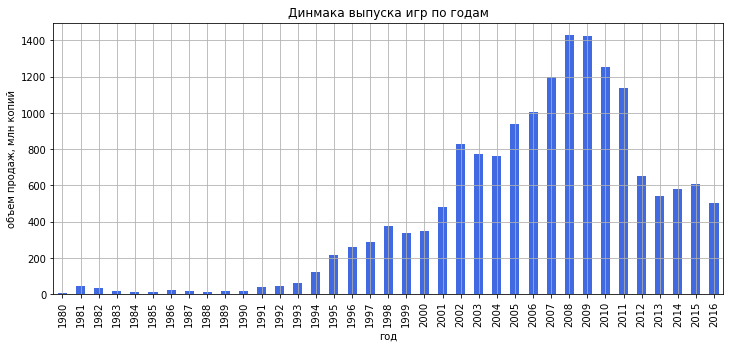

In [42]:
data.groupby('year')['year'].count().plot(kind='bar', \
                                               color='royalblue', \
                                               xlabel='год', \
                                               ylabel='объем продаж, млн копий', \
                                               title='Динмака выпуска игр по годам',\
                                               grid=True, style='-', \
                                               figsize=(12, 5))
plt.show;

In [43]:
data.groupby('year')['name'].count()

year
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     652
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64

***Резюме***

1. Динамика изменения количества выпускаемых игр по годам свидетельствует о том, что 
    - в период с 1980 по 1993 годы количество выпущенных игр было минимальным - около 30 новых игр в год
    - с 1995 года прослеживается активный рост количества релизов вплоть до 2008 года, когда прослеживался максимум - 1440 релизов в год
    - с 2009 года в течение пяти лет объем выпуска новых игр существенно падает до 547 релизов в 2013 году
    - начиная с 2014 года отрицательная динамика останавливается стабилизируясь на срднегодовом количестве выпускаемых игр около 550
2. Динамика релизов последних 4х лет в целом имеет сходство с динамикой периода 1996 - 1999 гг, после которого начался довольно активный рост количества релизов, и, тем не менее, несмотря на вполне возможное повторение динамики, целесообразно опираться на более пессимистичный прогноз - стабилизации или незначительного снижения показателя количества выпускаемых игр к уровню 2013-2015 гг, и, в рамках анализа потребительских предпочтений, больше внимания уделять именно этому периоду.

### Динамика продаж по годам

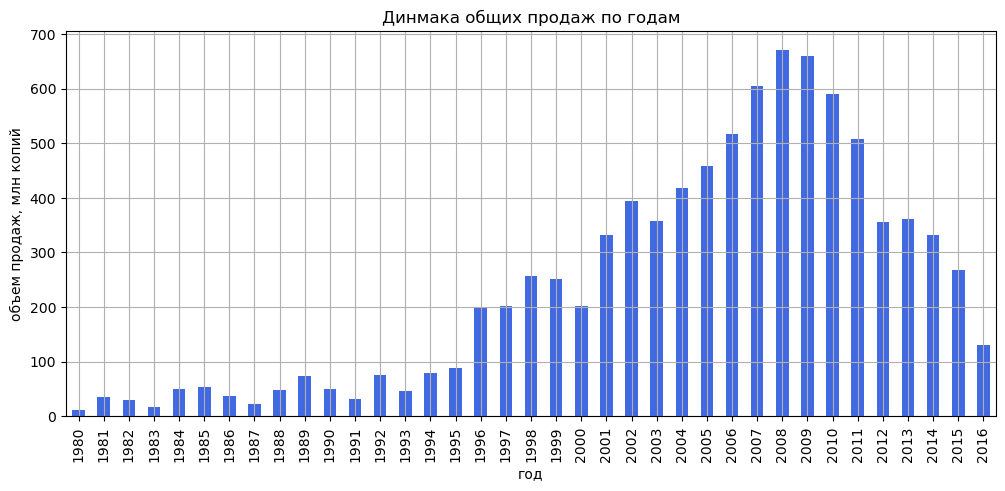

In [111]:
data.groupby('year')['total_sales'].sum().plot(kind='bar', \
                                               color='royalblue', \
                                               xlabel='год', \
                                               ylabel='объем продаж, млн копий', \
                                               title='Динмака общих продаж по годам',\
                                               grid=True, style='-', \
                                               figsize=(12, 5))
plt.show;

In [112]:
sales_by_year = data.pivot_table(index='year', values=('na_sales', 'eu_sales', 'jp_sales', 'other_sales'), aggfunc='sum')
sales_by_year.reset_index(inplace= True)
sales_by_year.columns = ['year','north_america', 'europe', 'japan', 'other_region']
sales_by_year.tail(10)

,year,north_america,europe,japan,other_region
27,2007,157.82,60.29,309.89,76.75
28,2008,181.14,60.25,348.69,81.42
29,2009,187.94,61.89,335.55,73.44
30,2010,171.42,59.49,300.65,58.57
31,2011,162.97,53.07,238.79,52.75
32,2012,114.58,51.80,153.26,36.19
33,2013,121.55,47.69,153.65,38.35
34,2014,122.74,39.69,132.27,36.83
35,2015,96.72,34.09,106.86,30.31
36,2016,51.22,19.31,44.93,14.48


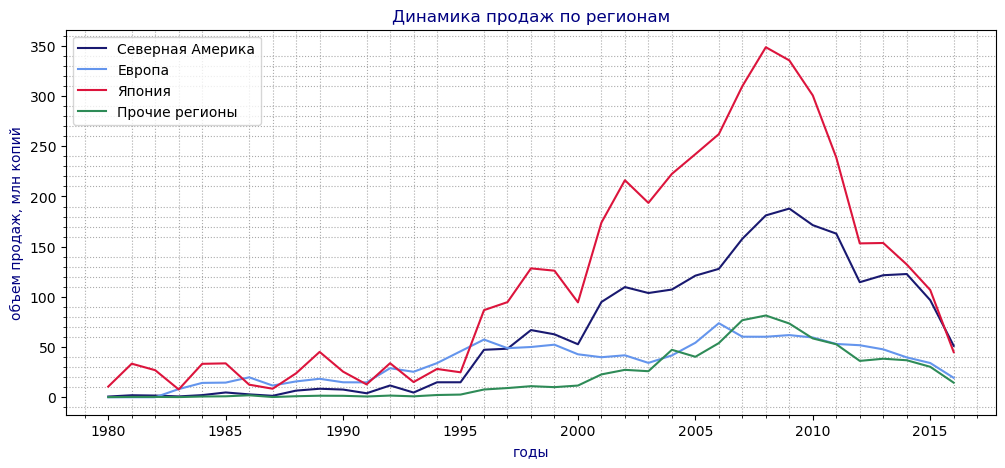

In [113]:
X = sales_by_year['year']
a = sales_by_year['north_america']
b = sales_by_year['europe']
c = sales_by_year['japan']
d = sales_by_year['other_region']
plt.figure(figsize=(12, 5))
plt.plot(X, a, color='midnightblue', label='Северная Америка') 
plt.plot(X, b, color='cornflowerblue', label='Европа')
plt.plot(X, c, color='crimson', label='Япония')
plt.plot(X, d, color='seagreen', label='Прочие регионы')
plt.xlabel("годы", color='navy') 
plt.ylabel("объем продаж, млн копий", color='navy') 
plt.title("Динамика продаж по регионам", fontsize=12, color='navy')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')
plt.legend() 
plt.show()

***Резюме***

Из представленной выше динамики продаж по годам видно, что
- с 1980 по 1995 гг. мировой объем продажне превышал отметки в 75 млн копий
- с 1996 года по 2008 (пик продаж) гг. наблюдался устойчивый рост
- начиная с 2009 года и по 2016 видна устойчивая тенденция сокращения объема рынка
- лидером по объему продаж является Япония, которая на пике - 2008 году почти в 2 раза превышала объемы продаж в Серверной Америке и, почти, в 6 раз рынок Европы.

### Изменение количества продаж в зависимости от платформы

Построим график зависимости объема продаж от платформы

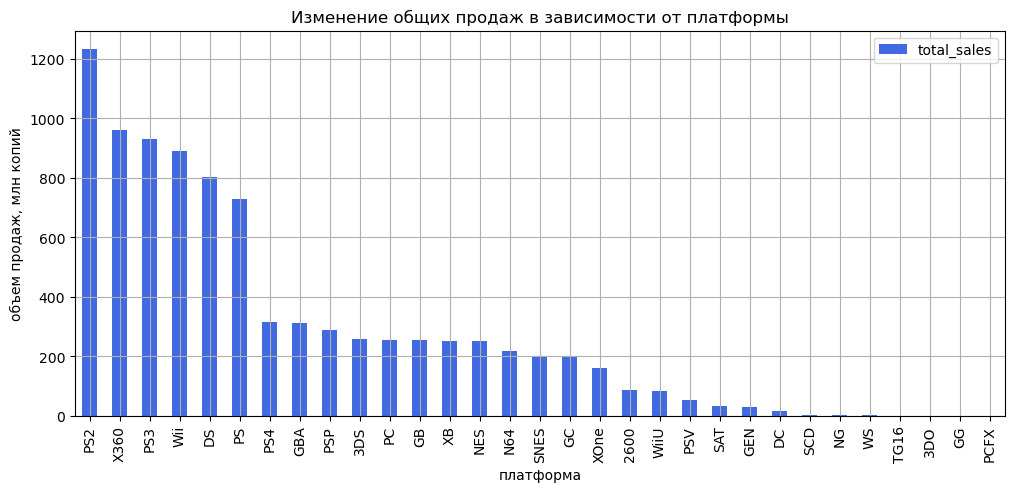

In [121]:
data.pivot_table(index='platform', values=('total_sales'), aggfunc='sum').sort_values(by='total_sales', ascending=False) \
    .plot(kind='bar', \
                                               color='royalblue', \
                                               xlabel='платформа', \
                                               ylabel='объем продаж, млн копий', \
                                               title='Изменение общих продаж в зависимости от платформы',\
                                               grid=True, style='-', \
                                               figsize=(12, 5))
plt.show;

На графике четко видны лидеры продаж - 6 платформ: PS2, X360, PS3, Wii, DS и PS

Посмотрим ретроспетивную динамику продаж по лидерам начиная с 1996 года по 2016 год, когда была самая активная фаза роста и последующего сокращения рынка компьютерных игр

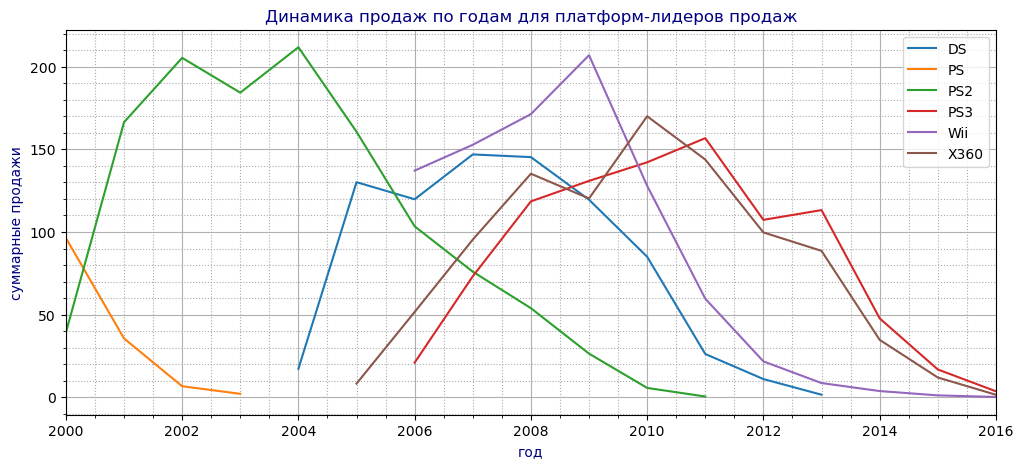

In [129]:
top_sales_list = list(data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).index[:6])
top_sales = data.query('platform in @top_sales_list')
top_sales.pivot_table(index='year', columns='platform', values='total_sales', aggfunc='sum') \
.plot( figsize = (12, 5), grid=True)
plt.xlim(2000, 2016)
plt.title('Динамика продаж по годам для платформ-лидеров продаж', color='navy')
plt.xlabel('год', color='navy')
plt.ylabel('суммарные продажи', color='navy')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')
plt.legend();

* Динамика продаж по годам для платформ-лидеров продаж отражает жизненный цикл платформы: активный рост продаж на старте, пик продаж и последующее постепенное снижение до 0 объемов продаж
* Посмотрим средний показатель длительности и медианы жизненного цикла платформ.

In [136]:
platform_life_cyc = data.query('year >= 1996 or total_sales >= 100') \
                        .pivot_table(index='platform', values='year', aggfunc=['min', 'max', 'median']).reset_index()
platform_life_cyc['period'] = platform_life_cyc['max'] - platform_life_cyc['min'] + 1 #добавлена единица для учета "нулевого" года
platform_life_cyc['mid'] = platform_life_cyc['max'] - platform_life_cyc['median'] + 1
f'Средняя длительность жизненного цикла {round(platform_life_cyc.period.mean())} лет, \
медиана жизненного цикла {round(platform_life_cyc.mid.mean())} лет'

C:\Users\Svetlana\AppData\Local\Temp\ipykernel_9980\2237874962.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  platform_life_cyc = data.query('year >= 1996 or total_sales >= 100') \


'Средняя длительность жизненного цикла 8 лет, медиана жизненного цикла 5 лет'

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Если ни чего не фильтровать, то получается другая цифра.</font>

In [51]:
# Комментарий ревьюера
temp = data.copy() 
time_life = temp.pivot_table(index='platform', values='year', aggfunc=['min', 'max']).reset_index()
time_life['life'] = time_life['max'] - time_life['min'] + 1 # в срок жизни платформы, должны входить границы диапазона, 
                                                            # поэтому +1
time_life['life'].median()

7.0

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Если изменим обработку пропусков в годах релиза и удалим все пропуски, то эта цифра будет меньше 8. Такая обработка пропусков привела к тому, что появились игры с годом релиза на платформах, которые уже ушли с рынка. Вот таким образом предобработка датасета может исказить анализ данных.</font>

Исходя из предположения, что распределение данных о продажах платформы можно определить как биноминальное распределение, а следовательно, также можно утвреждать, что период наибольшей прибыльности платформы находится в пределах межквартильного размаха, то есть для выяления платформ-потенциальных точек роста необходимо брать платформы, релиз игр на которых прошел не более 3х лет назад - т.е. начиная с 2014 года

***Резюме***

* Исходя из данных о суммарных объемах продаж - лидерами являются 6 платформ: PS2, X360, PS3, Wii, DS и PS4
* Анализ динамики продаж игр в разрезе платформ показал что платформа имеет жизненный цикл в среднем 8 лет, в рамках которого в среднем наибольший потенциал роста у платформ, релиз игр на которых прошел не более 3х лет назад

### Определение наиболее перспективных платформ

Определим список платформ, релиз игр на которох прошел начиная  2014 года

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно выбран актуальный период. 👍 Сейчас в наше динамичное время в бизнесе уже используются для прогноза периоды в 2-3 года.</font>

In [52]:
growth_platforms = data.query('year >= 2014')  #срез данных по плтаформам, релиз игр на которых прошел за последние 3 года              
growth_platforms_list = growth_platforms['platform'].unique().tolist()
print('Список платформ, которые потенциально могут в ближайшие 5-6 лет \nпоказывать существенный рост продаж:', growth_platforms_list)

Список платформ, которые потенциально могут в ближайшие 5-6 лет 
показывать существенный рост продаж: ['XOne', 'PSV', 'PC', 'PS3', 'PSP', '3DS', 'PS4', 'Wii', 'WiiU', 'X360']


Построим график продаж по годам для платформ, определенных как потенциально-растущие

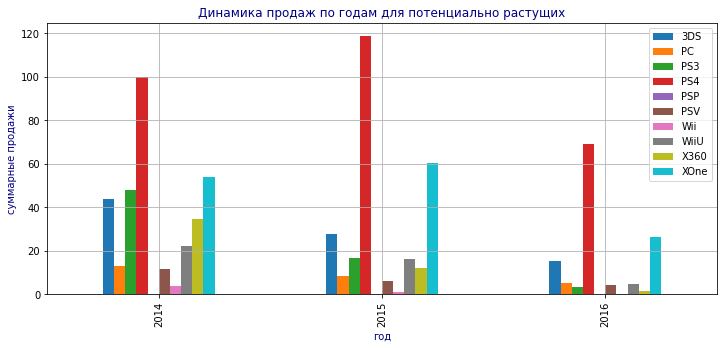

In [53]:
growth_platforms.pivot_table(index='year', columns='platform', values='total_sales', aggfunc='sum') \
.plot(kind='bar', figsize = (12, 5), grid=True)
plt.title('Динамика продаж по годам для потенциально растущих', color='navy')
plt.xlabel('год', color='navy')
plt.ylabel('суммарные продажи', color='navy')
plt.legend();

Из представленной диаграммы видно, что 
- наибольший объем продаж у платформы PS4, на втором месте по объему продаж - XOne
- наименьшийобъем продаж у PSP
- динамика продаж по всем платформам отрицательная

### Глобальные продажи в разрезе платформ

Оценим весь спектр данных о продажах по перспетивным платформам

In [54]:
growth_platforms['total_sales'].describe()

count    1689.000000
mean        0.431883
std         1.056109
min         0.010000
25%         0.030000
50%         0.100000
75%         0.350000
max        14.630000
Name: total_sales, dtype: float64

Посмотрим на распределение продаж за период с 2014 по 2016 годы среди перспективных платформ

In [55]:
growth_platform = growth_platforms.pivot_table(index='platform', values='total_sales', aggfunc='sum').reset_index()
growth_platform.sort_values(by='total_sales', ascending=False)

,platform,total_sales
3,PS4,288.15
9,XOne,140.36
0,3DS,86.68
2,PS3,68.18
8,X360,48.22
7,WiiU,42.98
1,PC,27.05
5,PSV,22.40
6,Wii,5.07
4,PSP,0.36


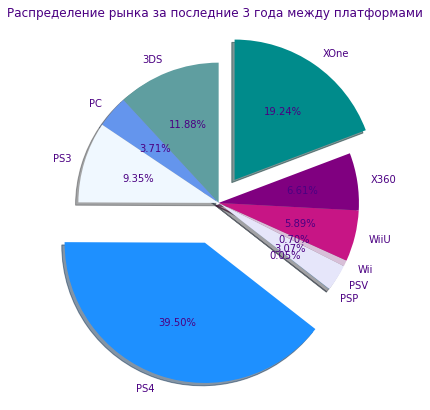

In [56]:
labels = list(growth_platform['platform'])
values = growth_platform['total_sales']
colors = ['cadetblue', 'cornflowerblue','aliceblue', 'dodgerblue', 'steelblue', \
          'lavender', 'thistle', 'mediumvioletred', 'purple', 'darkcyan']
explode=[0,0,0,0.3,0,0,0,0,0,0.2]
fig = plt.subplots(figsize=(7, 7))
plt.pie(values, colors=colors, labels=labels, explode=explode, \
        shadow=True, autopct='%1.2f%%', startangle=90, \
        textprops={'fontsize': 10, 'color': 'indigo'})
plt.title('Распределение рынка за последние 3 года между платформами', color='indigo')
plt.axis('equal')
plt.show()

Посмотрим распределение данных о продажах по платформам

In [57]:
growth_platforms.groupby('platform')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,212.0,0.408868,1.188368,0.01,0.0300,0.090,0.2500,11.68
PC,151.0,0.179139,0.329359,0.01,0.0200,0.060,0.2000,3.05
PS3,219.0,0.311324,0.633059,0.01,0.0400,0.110,0.3250,5.27
PS4,376.0,0.766356,1.614969,0.01,0.0575,0.185,0.6900,14.63
PSP,13.0,0.027692,0.027735,0.01,0.0100,0.020,0.0200,0.09
PSV,295.0,0.075932,0.141591,0.01,0.0200,0.040,0.0900,1.96
Wii,11.0,0.460909,0.625451,0.01,0.0350,0.180,0.7550,2.01
WiiU,73.0,0.588767,1.161467,0.01,0.0500,0.190,0.5700,7.09
X360,111.0,0.434414,0.628967,0.01,0.0700,0.180,0.5050,4.28


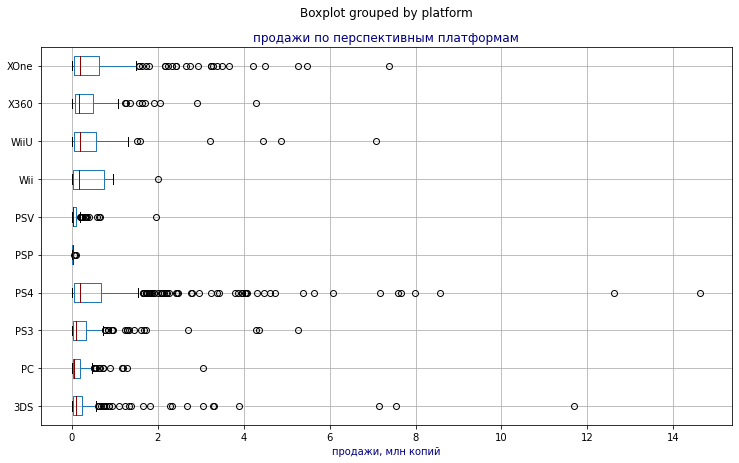

In [58]:
growth_platforms.boxplot(by='platform', column='total_sales', figsize=(12, 7), vert=False, medianprops=dict(color='darkred')) 
plt.title('продажи по перспективным платформам', color='navy')
plt.xlabel('продажи, млн копий', color='navy')
plt.show();

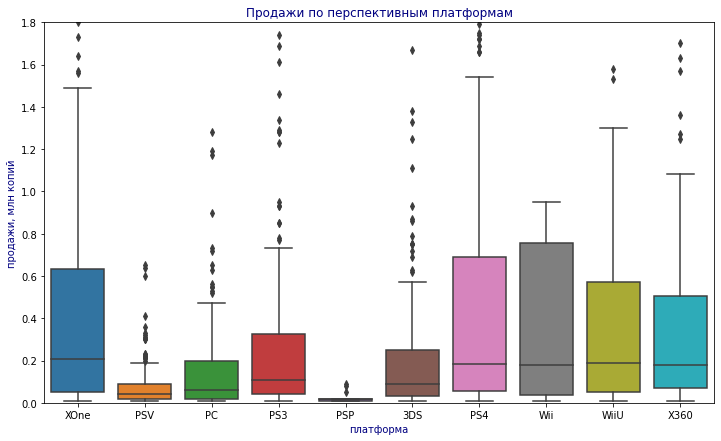

In [59]:
plt.figure(figsize=(12,7))
ax = sns.boxplot(data=growth_platforms, x='platform', y='total_sales')
ax.set(ylim=(0,1.8))
plt.title('Продажи по перспективным платформам', fontsize=12, color='navy')
plt.xlabel('платформа', fontsize=10, color='navy')
plt.ylabel('продажи, млн копий',fontsize=10, color='navy')
plt.show();

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Здесь уместна <b>вторая</b> диаграмма размаха со всеми максимумами продаж за актуальный период, а не только с масштабированными данными. А так мы не видим выбросы. Примерно вот так:</font>
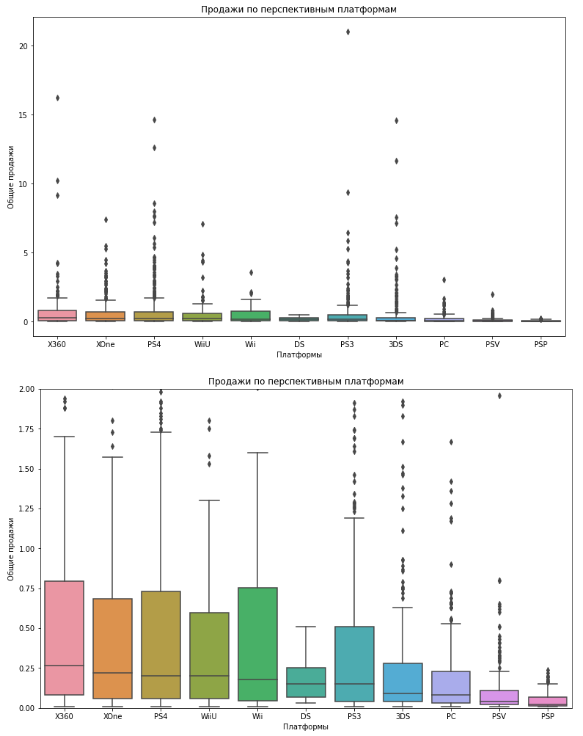

<font color='Blue'><b>Комментарий студента</b></font><br>
<font color='green'>дополнила анализ диагарммой без ограничения по Х</font>

***Резюме***

Из приведенных выше описания данных и диаграммы видно, что 
- самая продаваяеая платформа - PS4 - 288,15 млн копий, что составляет 39.5% всех продаж в период с 2014 по 2016 гг.
    - на PS4 за наблюдаемый период вышло 376 игр и медианным значением продажи одной игры в размере 185 тыс копий и выдающейся продажей игры в 14.63 млн копий
- следующая по популярности - XOne - 140,36 млн копий и 19.2% всех продаж в период с 2014 по 2016 гг.
    - на XOne за наблюдаемый период вышло 228 игр и медианным значением продажи одной игры в размере 180 тыс копий и выдающейся продажей игры в 7.39 млн копий
- медианное значение продаж по всем платформам - 0.1 млн копий, очень высокое стандартное отклонение - 1.06, при этом на диаграмме видно, что по разным платформам медианное значение существенно разнится: у лидеров продаж медиана находится примерно на уровне 0.2 млн копий, у аутсайдеров - стремится к 0
- по всем платформам наблюдается большое количесвто выбросов, что тажке подтвреждается очень высоким показателем стандартного отклонения в целом по продажам - 1.06 и максимальным показателем в 14.6 млн копий (продажа игр на платформе PS4)
- на диаграмме также видна диспропорция между 1 и 3 квартилем и верхним и нижним межквартильными размахами - квартильная ассиметрия

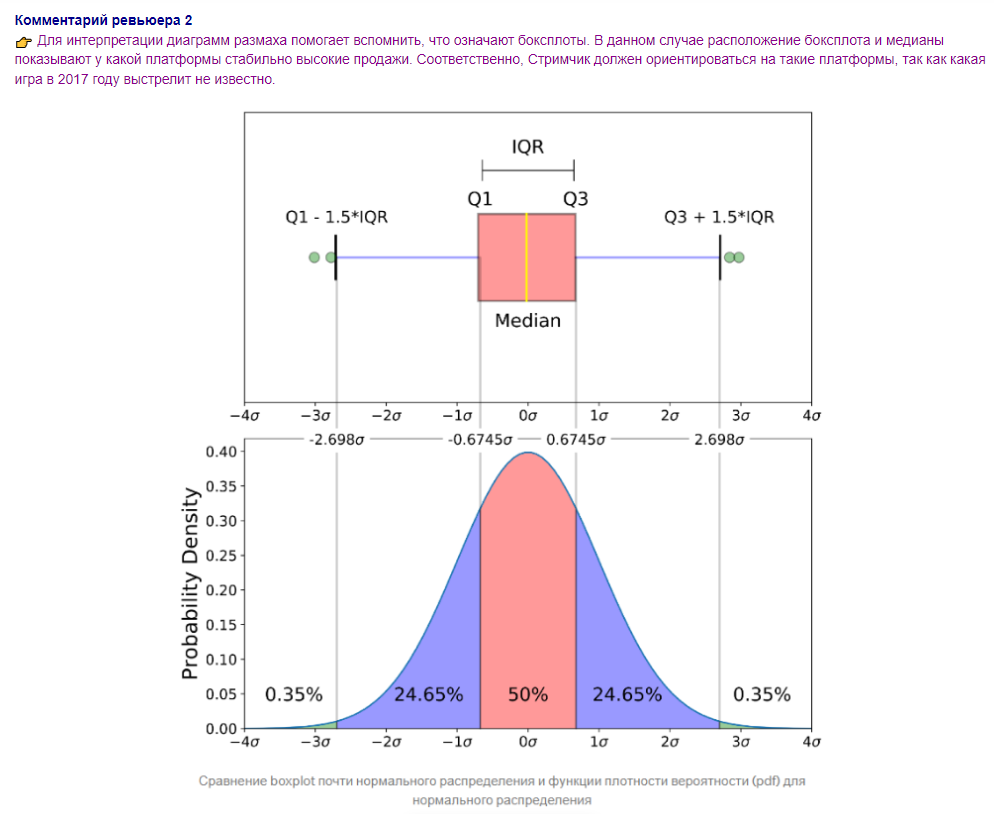

### Влияние отзывов на продажи

Для анализа влияния отзывов на продажи возьмем самую продаваемую из перспективных платформ - PS4. 

<font color='DarkBlue'><b>Комментарий ревьера</b></font><br>
<font color='Red'>🛠 В задании написано: <br><b>Возьмите данные за соответствующий актуальный период. Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год. <br>Не учитывайте в работе данные за предыдущие годы.</b> <br>После определения актуального периода дальнейший анализ должен проводиться только за этот период. Следует создать датасет с данными за актуальный период и далее проводить анализ только его.</font>

<font color='Blue'><b>Комментарий студента</b></font><br>
<font color='green'>анализ влияния отзывов проведен на дата-фрейме growth_platforms - содержит только игры с релизом в период с 2014-2016 гг.</font>

In [60]:
#определим корреляцию между продажами оценками критиков
growth_platforms.query('platform == "PS4" and critic_score != 101'). \
                loc[:,['total_sales', 'critic_score']]. \
                corr().style.format("{:,.2f}")

,total_sales,critic_score
total_sales,1.00,0.40
critic_score,0.40,1.00


In [61]:
#определим корреляцию между продажами и оценками пользователей
growth_platforms.query('platform == "PS4" and user_score != 11'). \
                loc[:,['total_sales', 'user_score']]. \
                corr().style.format("{:,.2f}")

,total_sales,user_score
total_sales,1.00,-0.04
user_score,-0.04,1.00


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Как-то оптом отфильтровываем заглушки. Если анализируем отзывы пользователей, то фильтруем заглушки по ним. Если анализируем отзывы критиков, то фильтруем эти заглушки. А вот удаление одновременно и тех и других ведет к необоснованному удалению данных и искажению расчета корреляции. См.код ниже.</font>

<font color='Blue'><b>Комментарий студента</b></font><br>
<font color='green'>исправила, оставила разделила расчет корреляции для разных оценок</font>

In [62]:
# Комментарий ревьюера
print(len(data.query("critic_score != 101")))
print(len(data.query("user_score != 11")))
print(len(data.query("critic_score != 101 & user_score != 11")))

7982
7462
6893


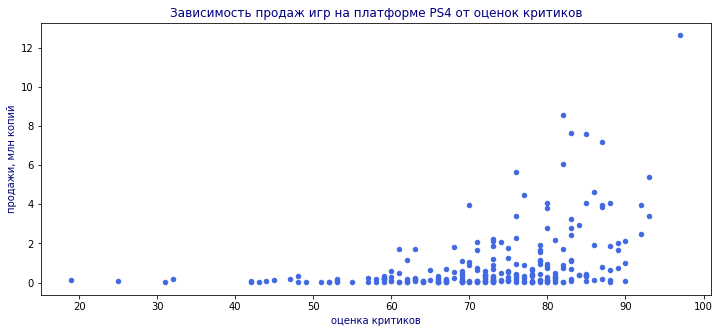

In [63]:
# построим диагармму рассеяния для продаж и оценки критиков платформы PS4
growth_platforms.query('platform == "PS4" and critic_score != 101') \
    .plot(kind='scatter', \
          x = 'critic_score', \
          y = 'total_sales', \
          figsize = (12,5), \
          color = 'royalblue')
plt.title('Зависимость продаж игр на платформе PS4 от оценок критиков', fontsize=12, color='navy')
plt.xlabel('оценка критиков', fontsize=10, color='navy')
plt.ylabel('продажи, млн копий',fontsize=10, color='navy')
plt.show();

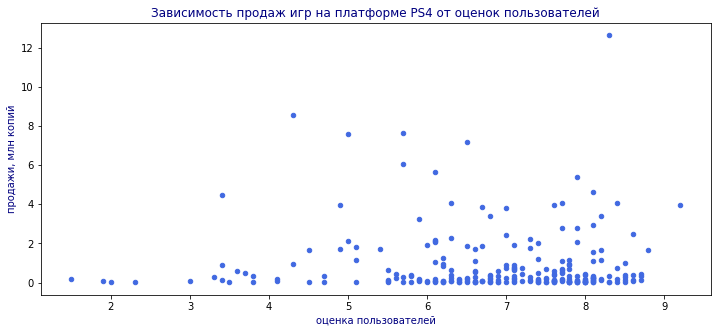

In [64]:
# построим диагармму рассеяния для продаж и оценки критиков платформы PS4
growth_platforms.query('platform == "PS4" and user_score != 11') \
    .plot(kind='scatter', \
          x = 'user_score', \
          y = 'total_sales', \
          figsize = (12,5), \
          color = 'royalblue')
plt.title('Зависимость продаж игр на платформе PS4 от оценок пользователей', fontsize=12, color='navy')
plt.xlabel('оценка пользователей', fontsize=10, color='navy')
plt.ylabel('продажи, млн копий',fontsize=10, color='navy')
plt.show();

Из представленных выше матриц корреляции и диаграмм рассеяния взаимосвязи оценок критиков и потребителей на продажи игр на платформе PS4 следует, что
- взаимосвязь оценок критиков крайне слабая - коэффициент корреляции 0.4,
- влияние оценок пользователей на продажи можно сказать отсутствует - коэффициент корреляции составляет -0.04

Посмотрим насколько выводы о воздействии оценок критиков и пользователей на продажи наиболее популярной в период с 2014 по 2016 гг. платформы совпадает с влиянием оценок на продажи игр на платформах, с релизом игр в последние 3 года

In [65]:
#определим корреляцию между продажами и критиковкритиков для всех платформ, с релизом игр последние 3 года
growth_platforms.query('critic_score != 101') \
                .loc[:,['total_sales', 'critic_score']]. \
                corr().style.format("{:,.2f}")

,total_sales,critic_score
total_sales,1.00,0.33
critic_score,0.33,1.00


In [66]:
#определим корреляцию между продажами и оценками пользователей для платформ, с релизом игр последние 3 года
growth_platforms.query('user_score != 11') \
                .loc[:,['total_sales', 'user_score']]. \
                corr().style.format("{:,.2f}")

,total_sales,user_score
total_sales,1.00,-0.01
user_score,-0.01,1.00


Анализ влияния оценок пользователей и критиков  целом на продажи перпективных платформ подтвердил выводы, сделанные при анализе влияния оценок на продажи наиболее популярной платфоры: влияние оценок крайне слабое.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Тут аналогичная ошибка. </font>

<font color='Blue'><b>Комментарий студента</b></font><br>
<font color='green'> исправлено анализ влияния оценок разделен </font>

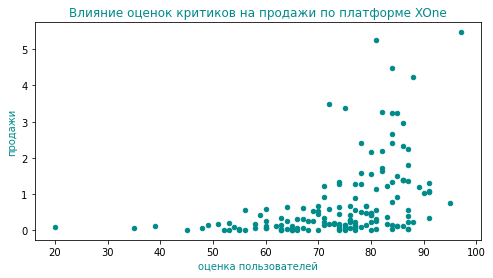

Корреляция оценки критиков и продаж по платформе XOne  = -0.07


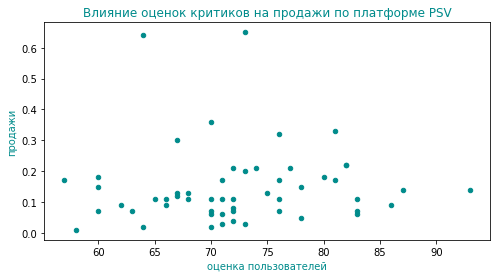

Корреляция оценки критиков и продаж по платформе PSV  = -0.17


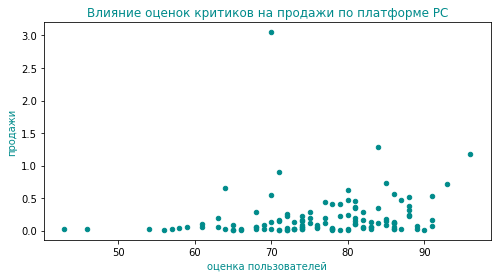

Корреляция оценки критиков и продаж по платформе PC  = -0.07


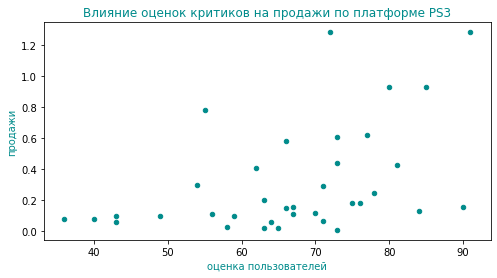

Корреляция оценки критиков и продаж по платформе PS3  = -0.17


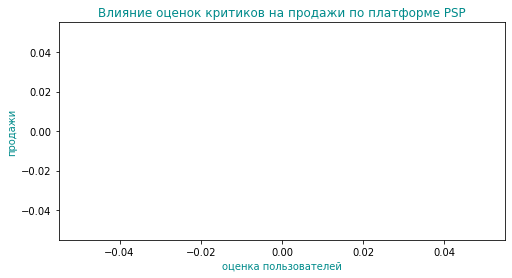

Корреляция оценки критиков и продаж по платформе PSP  = nan


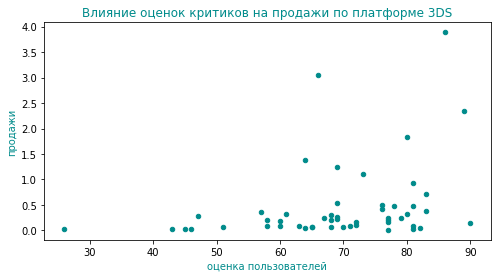

Корреляция оценки критиков и продаж по платформе 3DS  = 0.22


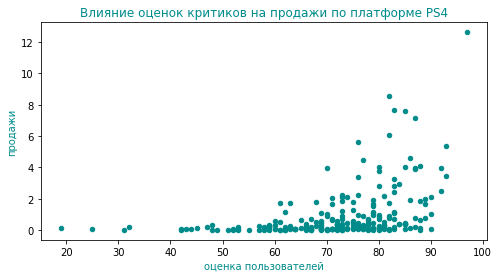

Корреляция оценки критиков и продаж по платформе PS4  = -0.04


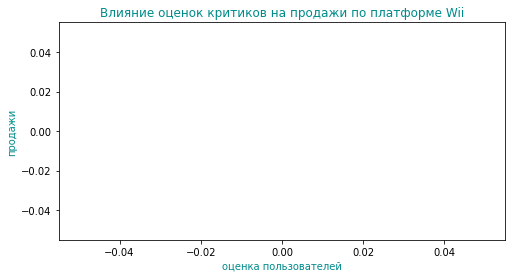

Корреляция оценки критиков и продаж по платформе Wii  = 1.0


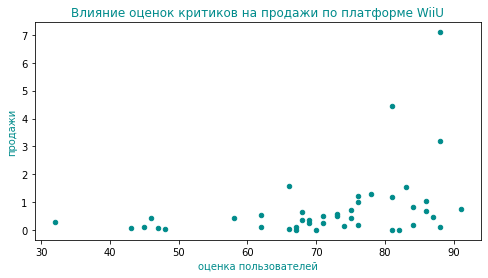

Корреляция оценки критиков и продаж по платформе WiiU  = 0.41


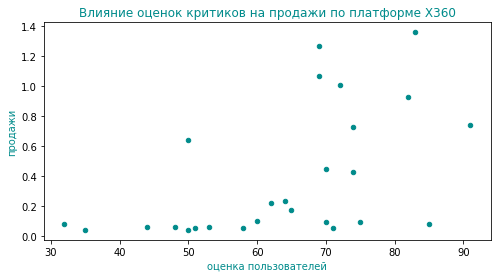

Корреляция оценки критиков и продаж по платформе X360  = -0.14


In [67]:
for name in growth_platforms_list:
    growth_platforms.query('platform == @name and critic_score != 101'). \
                    plot(x='critic_score', \
                          y='total_sales', \
                          kind='scatter', \
                          figsize=(8, 4), \
                          color='darkcyan')
    plt.title(f'Влияние оценок критиков на продажи по платформе {name}', color='darkcyan')
    plt.xlabel('оценка пользователей', color='darkcyan')
    plt.ylabel('продажи', color='darkcyan')
    plt.show()
    print(f'Корреляция оценки критиков и продаж по платформе {name}  =', \
          round(growth_platforms.query('platform == @name and user_score != 11')['user_score']. \
        corr(growth_platforms.query('platform == @name and user_score != 11')['total_sales']), 2))

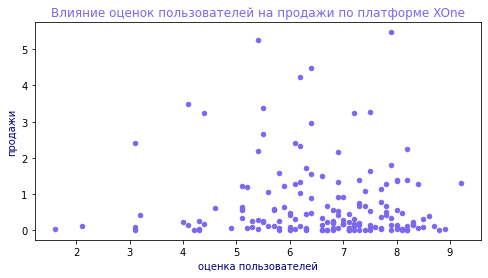

Корреляция пользовательской оценки и продаж по платформе XOne  = -0.07


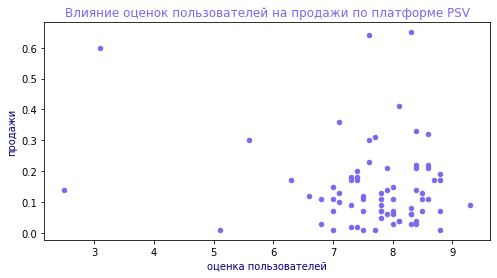

Корреляция пользовательской оценки и продаж по платформе PSV  = -0.17


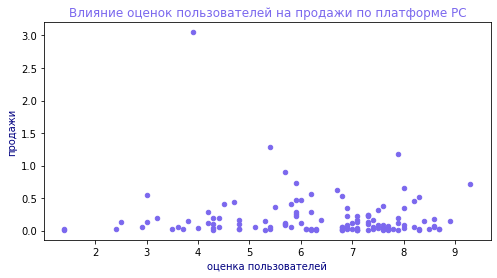

Корреляция пользовательской оценки и продаж по платформе PC  = -0.07


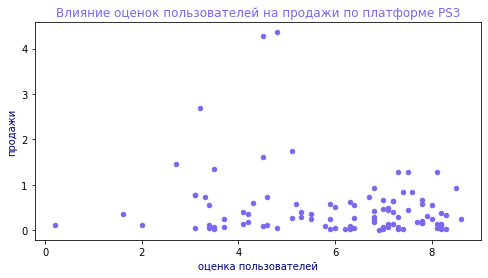

Корреляция пользовательской оценки и продаж по платформе PS3  = -0.17


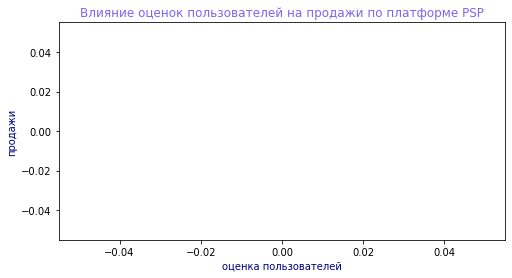

Корреляция пользовательской оценки и продаж по платформе PSP  = nan


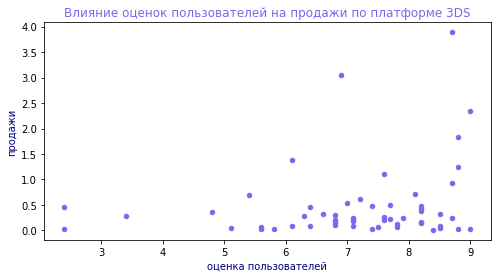

Корреляция пользовательской оценки и продаж по платформе 3DS  = 0.22


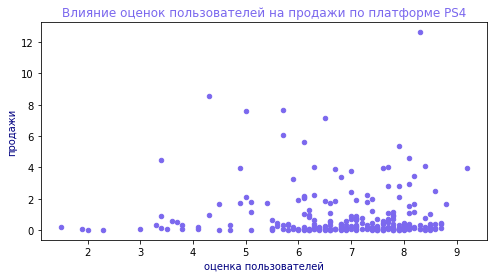

Корреляция пользовательской оценки и продаж по платформе PS4  = -0.04


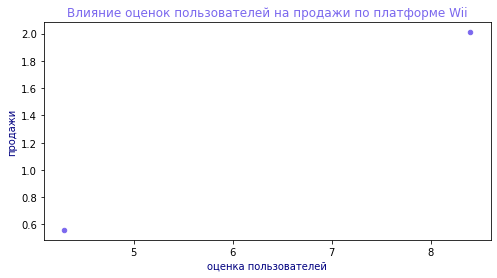

Корреляция пользовательской оценки и продаж по платформе Wii  = 1.0


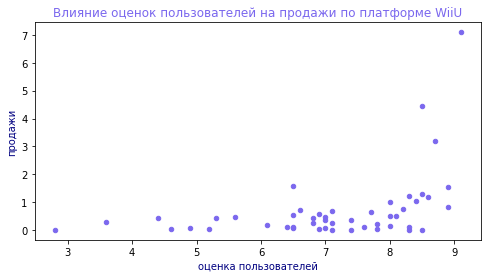

Корреляция пользовательской оценки и продаж по платформе WiiU  = 0.41


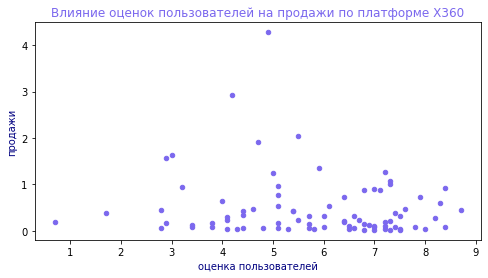

Корреляция пользовательской оценки и продаж по платформе X360  = -0.14


In [68]:
for name in growth_platforms_list:
    growth_platforms.query('platform == @name and user_score != 11'). \
                    plot(x='user_score', \
                          y='total_sales', \
                          kind='scatter', \
                          figsize=(8, 4), \
                          color='mediumslateblue')
    plt.title(f'Влияние оценок пользователей на продажи по платформе {name}', color='mediumslateblue')
    plt.xlabel('оценка пользователей', color='navy')
    plt.ylabel('продажи', color='navy')
    plt.show()
    print(f'Корреляция пользовательской оценки и продаж по платформе {name}  =', \
          round(growth_platforms.query('platform == @name and user_score != 11')['user_score']. \
        corr(growth_platforms.query('platform == @name and user_score != 11')['total_sales']), 2))

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, что раздельно отфильтровали заглушки!</font>

***Резюме***

* Анализ влияния оценки критиков и пользователей на продажи на примере наиболее продаваемой за период с 2014 по 2016 гг платформы PS4 показал крайне незначительное влияние пользовательской оценки на объем продаж (коэффициент корреляции составляет -0.04) и малое влияние оценки критиков (коэффициент корреляции 0.4).
* Проверка выявленной тенденции на платформах, с релизом игр последние 3 года, такое незначительное влияние оценок на продажи подтвердил.

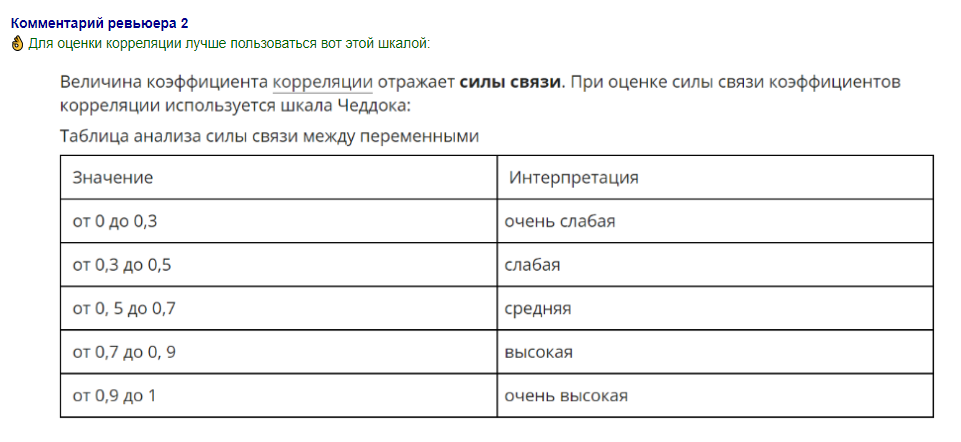

### Распределение игр по жанрам

<font color='DarkBlue'><b>Комментарий ревьюера</b></font>
<br><font color='Red'>🛠 Для анализа должен использоваться датасет актуального периода.</font>

<font color='Blue'><b>Комментарий студента</b></font>
<br><font color='green'>Исправлено - использован срез дата-сета - growth_platforms. Анализ на полном дата-сете удален</font>

Посмотрим на структуру текущего рынка в разрезе жанров

In [69]:
growth_platforms_by_genre = growth_platforms.pivot_table(index='genre', values=['name','total_sales'], aggfunc=({'name':'count', 'total_sales':'sum'})).reset_index()
growth_platforms_by_genre.columns = ['genre', 'game_amount', 'total_sales']
growth_platforms_by_genre['game_share'] = round((growth_platforms_by_genre['game_amount'] / (growth_platforms_by_genre['game_amount'].sum())* 100), 2) 
growth_platforms_by_genre['total_sales_share'] = round((growth_platforms_by_genre['total_sales'] / (growth_platforms_by_genre['total_sales'].sum()) * 100), 2) 
growth_platforms_by_genre.sort_values(by='game_share')

,genre,game_amount,total_sales,game_share,total_sales_share
5,Puzzle,14,2.21,0.83,0.30
11,Strategy,37,3.96,2.19,0.54
4,Platform,38,18.09,2.25,2.48
9,Simulation,44,13.13,2.61,1.80
2,Fighting,60,28.22,3.55,3.87
6,Racing,69,27.52,4.09,3.77
3,Misc,113,37.55,6.69,5.15
8,Shooter,128,170.94,7.58,23.43
10,Sports,161,109.48,9.53,15.01
1,Adventure,185,17.55,10.95,2.41


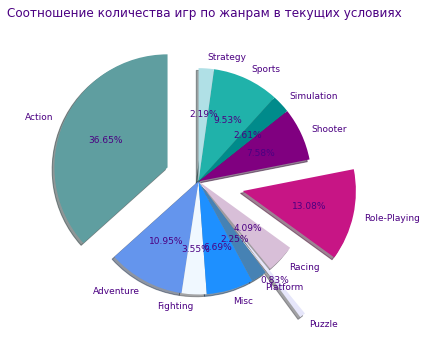

In [70]:
labels = growth_platforms_by_genre['genre']
values = growth_platforms_by_genre['game_amount']
colors = ['cadetblue', 'cornflowerblue','aliceblue', 'dodgerblue', 'steelblue', 'lavender', \
          'thistle', 'mediumvioletred', 'purple', 'darkcyan', 'lightseagreen', 'powderblue']
explode = [0.3,0,0,0,0,0.5,0,0.4,0,0,0,0]
fig = plt.subplots(figsize=(6, 6))
plt.pie(values, labels=labels, colors=colors, explode=explode, \
        shadow=True, autopct='%1.2f%%', startangle=90, \
        textprops={'fontsize': 9, 'color': 'indigo'})
plt.title('Соотношение количества игр по жанрам в текущих условиях', color='indigo')
plt.axis('equal')
plt.show()

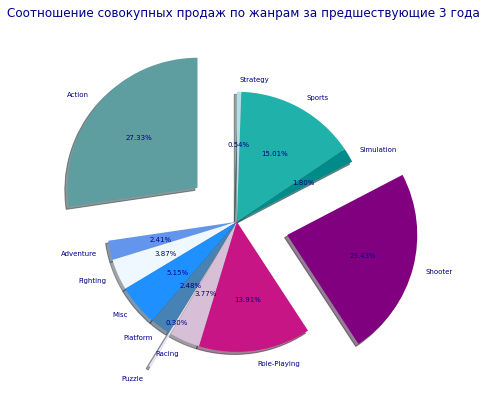

In [71]:
labels = growth_platforms_by_genre['genre']
values = growth_platforms_by_genre['total_sales']
colors = ['cadetblue', 'cornflowerblue','aliceblue', 'dodgerblue', 'steelblue', 'lavender', \
          'thistle', 'mediumvioletred', 'purple', 'darkcyan', 'lightseagreen', 'powderblue']
explode = [0.4,0,0,0,0,0.3,0,0,0.4,0,0,0]
fig = plt.subplots(figsize=(7, 7))
plt.pie(values, labels=labels, colors=colors, explode=explode, \
        shadow=True, autopct='%1.2f%%', startangle=90, \
        textprops={'fontsize': 7, 'color': 'darkblue'})
plt.title('Соотношение совокупных продаж по жанрам за предшествующие 3 года', color='darkblue')
plt.axis('equal')
plt.show()

In [72]:
growth_platforms.groupby('genre')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
genre,,,,,,,,
Action,619.0,0.322068,0.798181,0.01,0.0300,0.090,0.2800,12.62
Adventure,185.0,0.094865,0.203147,0.01,0.0200,0.030,0.0800,1.66
Fighting,60.0,0.470333,1.188053,0.01,0.0600,0.125,0.3200,7.55
Misc,113.0,0.332301,0.736999,0.01,0.0300,0.090,0.3200,5.27
Platform,38.0,0.476053,0.722561,0.01,0.0625,0.140,0.4675,3.21
Puzzle,14.0,0.157857,0.320629,0.01,0.0200,0.045,0.1000,1.19
Racing,69.0,0.398841,0.963716,0.01,0.0300,0.090,0.2500,7.09
Role-Playing,221.0,0.459005,1.177284,0.01,0.0500,0.110,0.3600,11.68
Shooter,128.0,1.335469,2.050567,0.01,0.1725,0.515,1.6175,14.63


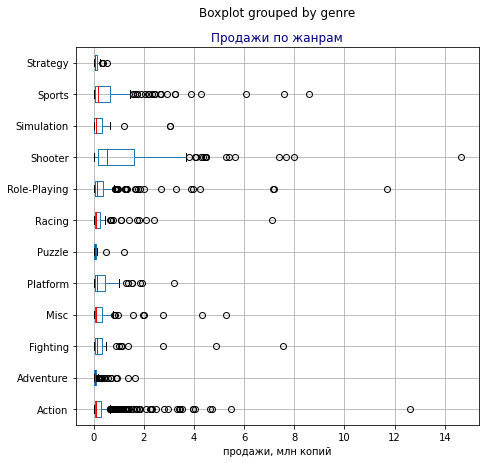

In [73]:
growth_platforms.boxplot(by='genre', column='total_sales', figsize=(7,7), vert=False, medianprops=dict(color='red'))
plt.title('Продажи по жанрам', color='navy')
plt.xlabel('продажи, млн копий')
plt.show();

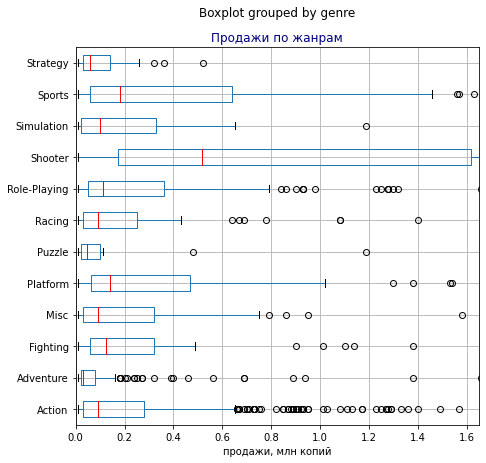

In [74]:
growth_platforms.boxplot(by='genre', column='total_sales', figsize=(7,7), vert=False, medianprops=dict(color='red'))
plt.xlim(0, 1.65) 
plt.title('Продажи по жанрам', color='navy')
plt.xlabel('продажи, млн копий')
plt.show();

***Резюме***

Из представленных диаграмм видно, что за последние 3 года сформировалась следующая структура рынка и жанровые предпочтения пользователей:
- **наибольшее количество игр** представлено **в жанре Action** - c долей 36.65%
    * следующий по количеству игр жанр Role-Playing с долей 13.08% 
- наименьшее количество игр представлено в жанре Puzzle - 0.83% 
- **наиболее продаваемые жанр Action** - 27.33 % совокупного объема продаж за последние 3 года
    * второе место по популярности также занимает жанр Shooter с долей в продажах 23.43% 
- наименее продаваемые игры в жанре Puzzle с долей 0.30%
- сравнение медианных продаж по жанрам показало, что **наиболее популярные игры в жанре Shooter (515 тыс. копий) и Sports (180 тыс. копий)**, тогда как у лидера по продаваемости Action медиана составляет всего 90 тыс копий

<font color='DarkBlue'><b>Комментарий ревьюера 3</b></font><br>
<font color='DarkGreen'>👌 В проекте под "прибыльностью" понимается наличие устойчивого спроса пользователей на данный жанр. Можно сделать уникальный сюжет, быстрый движок, красивую графику и вложить немеряно денег в рекламу и продажи игры подпрыгнут. Но нам лучше выбирать игру из жанра, на которой есть постоянный спрос независимо от маркетинговых усилий производителей игр.<br>
Это хороший пример, когда на одних и тех же данных разные диаграммы дают разный анализ. Визуализация это не только красивое представление табличных данных, а еще и инструмент анализа.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Здесь попали в ловушку, что максимальные продажи являются самыми прибыльными. Но в данных продажи по жанру для разных платформ, и если одна платформа со своей одной игрой в данном жанре выстрелила, а остальные провалились, то все равно будет виден максимум общих продаж. Но для прибыльности нужны стабильные жанры, который приносят доход не зависимо от платформы, значит на этот жанр есть устойчивый спрос.</font><br>
<font color='Red'>🛠 По этому лучше добавить сравнение медианных продаж, проиллюстрировав их диаграммами размаха и изменить промежуточные выводы.</font>

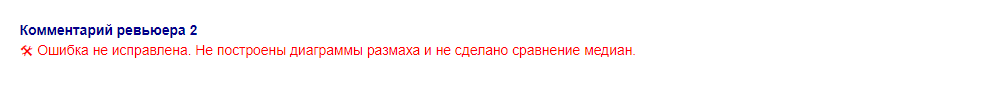

<font color='Blue'><b>Комментарий студента</b></font><br>
<font color='green'>исправлено</font><br>

## Данные о пользователях

###  Пользователи региона Северная Америка

Сформируем таблицу наиболее популярных платформ и жанров по региону Северная Америка.

In [75]:
#сформируем таблицу с топ-5 платформ по региону Северная Америка
na_platform = growth_platforms.pivot_table(index='platform', values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index()
na_platform.columns=['platform', 'platform_sales']
na_platform['platform_sales_share'] = round((na_platform['platform_sales'] / na_platform['platform_sales'].sum() * 100), 2)
na_top_platform = na_platform.loc[:4]


#сформируем таблицу с топ-5 жанров по региону Северная Америка
na_genre = growth_platforms.pivot_table(index='genre', values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index()
na_genre.columns=['genre', 'genre_sales']
na_genre['genre_sales_share'] = round((na_genre['genre_sales'] / na_genre['genre_sales'].sum() * 100), 2)
na_top_genre = na_genre.loc[:4]

# Объединим таблицы
na_top = na_top_platform.join(na_top_genre)
print('ТОП-5 платформ и жанров по региону Северная Америка')
na_top

ТОП-5 платформ и жанров по региону Северная Америка


,platform,platform_sales,platform_sales_share,genre,genre_sales,genre_sales_share
0,PS4,98.61,34.71,Shooter,79.02,27.82
1,XOne,81.27,28.61,Action,72.53,25.53
2,X360,28.30,9.96,Sports,46.13,16.24
3,3DS,22.64,7.97,Role-Playing,33.47,11.78
4,PS3,22.05,7.76,Misc,15.05,5.30


Посмотрим какой рейтинг возрастной категории наиболее популярен в этом регионе

In [76]:
na_esrb = growth_platforms.pivot_table(index='rating', values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index()
na_esrb['esrb_share'] = round((na_esrb['na_sales'] / na_esrb['na_sales'].sum() * 100), 2)
na_esrb

,rating,na_sales,esrb_share
0,M,96.42,33.94
1,unknown,64.72,22.78
2,E,50.74,17.86
3,T,38.95,13.71
4,E10+,33.23,11.70


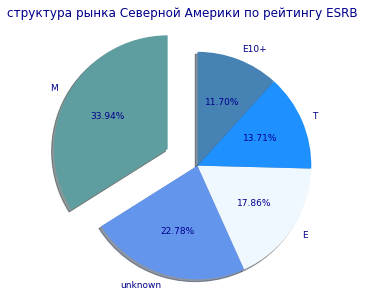

In [77]:
labels = na_esrb['rating']
values = na_esrb['na_sales']
colors = ['cadetblue', 'cornflowerblue','aliceblue', 'dodgerblue', 'steelblue']
explode = [0.3,0,0,0,0]
fig = plt.subplots(figsize=(5, 5))
plt.pie(values, labels=labels, colors=colors, explode=explode, \
        shadow=True, autopct='%1.2f%%', startangle=90, \
        textprops={'fontsize': 9, 'color': 'darkblue'})
plt.title('структура рынка Северной Америки по рейтингу ESRB', color='darkblue')
plt.axis('equal')
plt.show()

Таким образом, мы видим, что по региону Северная Америка за последние 3 года лидирующее положение на рынке занимает платформа PS4 с долей 34.71% всего рынка и жанр Shooter с долей рынка 27.81%
На представленной выше диаграмме видно, что 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 33.96% рынка. Наименее популярны игры с рейтингом «E10+»(«Everyone 10 and older») — «Для всех от 10 лет и старше»

###  Пользователи региона Европа

Сформируем таблицу наиболее популярных платформ и жанров по региону Европа.

In [78]:
#сформируем таблицу с топ-5 платформ по региону Европа
eu_platform = growth_platforms.pivot_table(index='platform', values='eu_sales', aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index()
eu_platform.columns=['platform', 'platform_sales']
eu_platform['platform_sales_share'] = round((eu_platform['platform_sales'] / eu_platform['platform_sales'].sum() * 100), 2)
eu_top_platform = eu_platform.loc[:4]


#сформируем таблицу с топ-5 жанров по региону Европа
eu_genre = growth_platforms.pivot_table(index='genre', values='eu_sales', aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index()
eu_genre.columns=['genre', 'genre_sales']
eu_genre['genre_sales_share'] = round((eu_genre['genre_sales'] / eu_genre['genre_sales'].sum() * 100), 2)
eu_top_genre = eu_genre.loc[:4]


# Объединим таблицы
print('ТОП-5 платформ и жанров по региону Европа')
eu_top_platform.join(eu_top_genre)

ТОП-5 платформ и жанров по региону Европа


,platform,platform_sales,platform_sales_share,genre,genre_sales,genre_sales_share
0,PS4,130.04,48.04,Action,74.68,27.59
1,XOne,46.25,17.09,Shooter,65.52,24.21
2,PS3,25.54,9.44,Sports,45.73,16.89
3,PC,17.97,6.64,Role-Playing,28.17,10.41
4,3DS,16.12,5.96,Racing,14.13,5.22


Таким образом, мы видим, что по региону Европа за последние 3 года лидирующее положение на рынке занимает платформа PS4 с долей 48.00% и жанр Action с долей 27.66%

Посмотрим какой рейтинг возрастной категории наиболее популярен в Европе

In [79]:
eu_esrb = growth_platforms.pivot_table(index='rating', values='eu_sales', aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index()
eu_esrb['esrb_share'] = round((eu_esrb['eu_sales'] / eu_esrb['eu_sales'].sum() * 100), 2)
eu_esrb

,rating,eu_sales,esrb_share
0,M,93.44,34.52
1,unknown,58.95,21.78
2,E,58.06,21.45
3,T,34.07,12.59
4,E10+,26.16,9.66


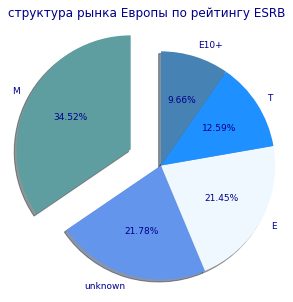

In [80]:
labels = eu_esrb['rating']
values = eu_esrb['eu_sales']
colors = ['cadetblue', 'cornflowerblue','aliceblue', 'dodgerblue', 'steelblue']
explode = [0.3,0,0,0,0]
fig = plt.subplots(figsize=(5, 5))
plt.pie(values, labels=labels, colors=colors, explode=explode, \
        shadow=True, autopct='%1.2f%%', startangle=90, \
        textprops={'fontsize': 9, 'color': 'darkblue'})
plt.title('структура рынка Европы по рейтингу ESRB', color='darkblue')
plt.axis('equal')
plt.show()

На приведенной выше диаграмме видно, что 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 34.58% рынка. Наименее популярны игры с рейтингом «E10+»(«Everyone 10 and older») — «Для всех от 10 лет и старше»

###  Пользователи региона Япония

Сформируем таблицу наиболее популярных платформ и жанров по региону Япония.

In [81]:
#сформируем таблицу с топ-5 платформ по региону Япония
jp_platform = growth_platforms.pivot_table(index='platform', values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index()
jp_platform.columns=['platform', 'platform_sales']
jp_platform['platform_sales_share'] = round((jp_platform['platform_sales'] / jp_platform['platform_sales'].sum() * 100), 2)
jp_top_platform = jp_platform.loc[:4]


#сформируем таблицу с топ-5 жанров по региону Япония
jp_genre = growth_platforms.pivot_table(index='genre', values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index()
jp_genre.columns=['genre', 'genre_sales']
jp_genre['genre_sales_share'] = round((jp_genre['genre_sales'] / jp_genre['genre_sales'].sum() * 100), 2)
jp_top_genre = jp_genre.loc[:4]


# Объединим таблицы
print('ТОП-5 платформ и жанров по региону Япония')
jp_top_platform.join(jp_top_genre)

ТОП-5 платформ и жанров по региону Япония


,platform,platform_sales,platform_sales_share,genre,genre_sales,genre_sales_share
0,3DS,44.24,47.52,Role-Playing,31.16,33.47
1,PS4,15.02,16.13,Action,29.58,31.78
2,PSV,14.54,15.62,Fighting,6.37,6.84
3,PS3,11.22,12.05,Misc,5.61,6.03
4,WiiU,7.31,7.85,Shooter,4.87,5.23


Таким образом, мы видим, что по региону Япония за последние 3 года лидирующее положение на рынке занимает платформа 3DS с долей 47.52% и жанр Role-Playing с долей 33.47%

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вот, что у нас написано в задании: <br><b>Шаг 4. Составьте портрет пользователя каждого региона<br>
Определите для пользователя каждого региона (NA, EU, JP):<br>...................<br>Самые популярные жанры (топ-5). Поясните разницу.</b><br>А это не сделано.</font>

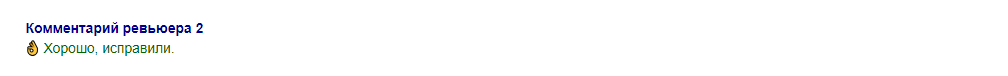

<font color='Blue'><b>Комментарий студента</b></font><br>
<font color='green'> Выведены ТОП5 и жанров и платформ. (вы наверно просто не заметили. Причины - разницы в предпочтениях - дописала в резюме по разделу</font>

Посмотрим какой рейтинг возрастной категории наиболее популярен в Японии

In [82]:
jp_esrb = growth_platforms.pivot_table(index='rating', values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index()
jp_esrb['esrb_share'] = round((jp_esrb['jp_sales'] / jp_esrb['jp_sales'].sum() * 100), 2)
jp_esrb

,rating,jp_sales,esrb_share
0,unknown,56.90,61.12
1,T,14.78,15.88
2,E,8.94,9.60
3,M,8.01,8.60
4,E10+,4.46,4.79


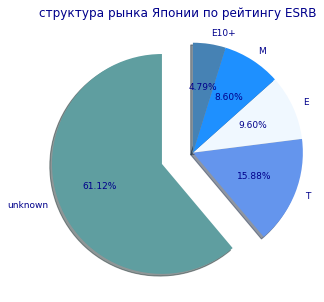

In [83]:
labels = jp_esrb['rating']
values = jp_esrb['jp_sales']
colors = ['cadetblue', 'cornflowerblue','aliceblue', 'dodgerblue', 'steelblue']
explode = [0.3,0,0,0,0]
fig = plt.subplots(figsize=(5, 5))
plt.pie(values, labels=labels, colors=colors, explode=explode, \
        shadow=True, autopct='%1.2f%%', startangle=90, \
        textprops={'fontsize': 9, 'color': 'darkblue'})
plt.title('структура рынка Японии по рейтингу ESRB', color='darkblue')
plt.axis('equal')
plt.show()

61.12% рынка Японии - игры без рейтинга ERSB

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Вот такая проблема была с рейтингом. <br>
А дело в том, что если посмотреть в инете, что из себя представляет рейтинг ESRB, то окажется, что он предназначен для маркировки игр для США и Канады. И логично, что для других регионов он не заполняется. А в Японии есть свой рейтинг, свой рейтинг есть в ЕС и отдельно в Германии, Австралии и т.д., но по ним в датасете нет данных. То есть, в данном случае пропуск имеет признак, что игра выпущена не в Северо-Американском регионе. Необходимо шире смотреть на исходный датасет, так как за цифрами находятся реальные бизнес-процессы. Это необходимо учитывать при предобработке данных.</font>

###   Пользователи прочих регионов

In [84]:
#сформируем таблицу с топ-5 платформ по прочим регионам
other_platform = growth_platforms.pivot_table(index='platform', values='other_sales', aggfunc='sum').sort_values(by='other_sales', ascending=False).reset_index()
other_platform.columns=['platform', 'platform_sales']
other_platform['platform_sales_share'] = round((other_platform['platform_sales'] / other_platform['platform_sales'].sum() * 100), 2)
other_top_platform = other_platform.loc[:4]


#сформируем таблицу с топ-5 жанров по прочим регионам
other_genre = growth_platforms.pivot_table(index='genre', values='other_sales', aggfunc='sum').sort_values(by='other_sales', ascending=False).reset_index()
other_genre.columns=['genre', 'genre_sales']
other_genre['genre_sales_share'] = round((other_genre['genre_sales'] / other_genre['genre_sales'].sum() * 100), 2)
other_top_genre = other_genre.loc[:4]


# Объединим таблицы
print('ТОП-5 платформ и жанров по прочим регионам')
other_top_platform.join(other_top_genre)

ТОП-5 платформ и жанров по прочим регионам


,platform,platform_sales,platform_sales_share,genre,genre_sales,genre_sales_share
0,PS4,44.48,54.50,Action,22.57,27.65
1,XOne,12.52,15.34,Shooter,21.53,26.38
2,PS3,9.37,11.48,Sports,14.36,17.59
3,X360,4.35,5.33,Role-Playing,8.64,10.59
4,3DS,3.68,4.51,Misc,4.03,4.94


По прочим регионам за последние 3 года лидирующее положение на рынке занимает платформа PS4 с долей 54.47% и жанр Action с долей 27.69%

Посмотрим какой рейтинг возрастной категории наиболее популярен в оставшихся регионах

In [85]:
other_esrb = growth_platforms.pivot_table(index='rating', values='other_sales', aggfunc='sum').sort_values(by='other_sales', ascending=False).reset_index()
other_esrb['esrb_share'] = round((other_esrb['other_sales'] / other_esrb['other_sales'].sum() * 100), 2)
other_esrb

,rating,other_sales,esrb_share
0,M,28.67,35.13
1,unknown,18.40,22.54
2,E,15.39,18.86
3,T,11.33,13.88
4,E10+,7.83,9.59


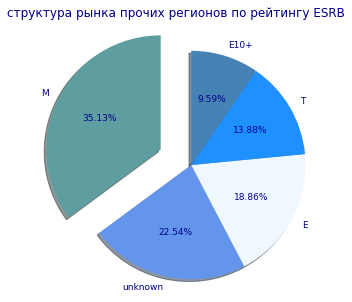

In [86]:
labels = other_esrb['rating']
values = other_esrb['other_sales']
colors = ['cadetblue', 'cornflowerblue','aliceblue', 'dodgerblue', 'steelblue']
explode = [0.3,0,0,0,0]
fig = plt.subplots(figsize=(5, 5))
plt.pie(values, labels=labels, colors=colors, explode=explode, \
        shadow=True, autopct='%1.2f%%', startangle=90, \
        textprops={'fontsize': 9, 'color': 'darkblue'})
plt.title('структура рынка прочих регионов по рейтингу ESRB', color='darkblue')
plt.axis('equal')
plt.show()

На приведенной выше диаграмме видно, что 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 35.16% рынка. Наименее популярны игры с рейтингом «E10+»(«Everyone 10 and older») — «Для всех от 10 лет и старше»

***Резюме:***

- По региону **Северная Америка** за последние 3 года
    - лидирующее положение на рынке занимает платформа PS4 с долей рынка 34.71% и жанр Shooter с долей рынка 27.81%
    - 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 33.96% рынка.
- По региону **Европа** за последние 3 года
    - лидирующее положение на рынке занимает платформа PS4 с долей рынка 48.00% и жанр Shooter с долей рынка 27.66%
    - 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 34.58% рынка.
- По региону **Япония** за последние 3 года
    - лидирующее положение на рынке занимает платформа 3DS с долей 47.52% и жанр Role-Playing с долей 33.47%.
    - 61.12% рынка - игры без рейтинга ERSB, что связано в первую очередь с тем, что рейтинг предназначен для маркировки развлекательного контента стран Северной Америки
- По **прочим регионам** за последние 3 года
    - лидирующее положение на рынке занимает платформа PS4 с долей 54.47% и жанр Action с долей 27.69%
    - 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 35.16% рынка
**Таким образом мы видим, что в целом по миру предпочтения по платформам совпадают, лидирует платформа PS4, за исключением Японии, где пользовательские предпочтения сохранаяются за платформой японского производства Nintendo 3DS. Жанровые предпочтения Европы и Серверной Америки совпали - Shooter, Япония опять не вписалась в общий тренд и выбрала Role-Playing. Полагаю, что объяснить это можно в первую очередь отличием японского менталитета от североамериканского и европейского.**

## Проверка гипотез

Проверку гипотез предлагается осуществлять с уровнем статистической значимости 1% - достаточный уровень статистической значимости, определяющей вероятность ошибки при выявлении закономреностей 

### Гипотеза 1

**Гипотеза 1** - Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Для проверки такой гипотезы нам необходимо провести t-тест двух независимых выборок: пользовательский рейтинг платформы Xbox One и пользовательский рейтинг платформы РС. 

- Оценим гипотезу **Ho** о том, что **средние пользовательские рейтинги платформ Xbox One и PC равны** - проведем двухвыборочный t-тест с проверкой двусторонней гипотезы с уровнем статитстической значимости равным 0,01.
-  В качестве альтернативной гипотезы **Н1** примем гипотезу, что **средние пользовательские рейтинги платформ Xbox One и PC не равны**

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, правильно сформулированы гипотезы.</font>

In [87]:
growth_platforms.query('platform == "XOne" and user_score != 11')['user_score'].describe()

count    165.000000
mean       6.594545
std        1.375139
min        1.600000
25%        5.800000
50%        6.800000
75%        7.600000
max        9.200000
Name: user_score, dtype: float64

In [88]:
growth_platforms.query('platform == "PC" and user_score != 11')['user_score'].describe()

count    122.000000
mean       6.298361
std        1.703278
min        1.400000
25%        5.325000
50%        6.800000
75%        7.600000
max        9.300000
Name: user_score, dtype: float64

Из описания двух выборок следует, что размер и стандартное отклонение отличается: для Xbox One - 165 и 1.375, для PC - 123 и 1.708 соответственно. Это означает, что проведении ttest необходимо использовать аргумент equal_var=False 

In [89]:
result_hypo_1 = st.ttest_ind \
                (growth_platforms.query('platform == "XOne" and user_score != 11')['user_score'], \
                growth_platforms.query('platform == "PC" and user_score != 11')['user_score'], \
                equal_var=False,
                alternative='two-sided')
print(f'p-значение: {result_hypo_1.pvalue}')

alpha = 0.01
if result_hypo_1.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')


p-значение: 0.11601398086669047
Не получилось отвергнуть нулевую гипотезу


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, что отфильтровали заглушки.</font><br>
<font color='DarkGreen'>👌 Правильно, что для тестирования гипотез использован двусторонний t-тест.</font>

***Резюме:***

Гипотезу о том, что **средние пользовательские рейтинги платформ Xbox One и PC одинаковые не удалось опровергнуть**. Возможно предположить, что средние оценки при установленном уровне значимости в 5 % равны.

### Гипотеза 2 

**Гипотеза 2** состоит в преположении, что средние пользовательские рейтинги жанров Action и Sports разные.

Для проверки такой гипотезы нам необходимо провести t-тест двух независимых выборок: пользовательский рейтинг жанра Action и пользовательский рейтинг жанра Sports. 

- Оценим гипотезу **Но** о том, что **cредние пользовательские рейтинги жанров Action и Sports равны** - проведем правосторонний t-тест для выборки игр жанра Action, с уровнем статитической значимости 0.01
-  В качестве альтернативной гипотезы **Н1** примем гипотезу, что **cредние пользовательские рейтинги жанров Action и Sports не равны**

In [90]:
growth_platforms.query('genre == "Action" and user_score != 11')['user_score'].describe()

count    297.000000
mean       6.760606
std        1.377852
min        2.000000
25%        6.100000
50%        7.100000
75%        7.700000
max        9.000000
Name: user_score, dtype: float64

In [91]:
growth_platforms.query('genre == "Sports" and user_score != 11')['user_score'].describe()

count    127.000000
mean       5.225197
std        1.856604
min        0.200000
25%        4.000000
50%        5.500000
75%        6.650000
max        8.800000
Name: user_score, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что показаны дополнительно средние пользовательские рейтинги и по платформам, и по жанрам, как иллюстрации не противоречивости наших гипотез.</font>

Из описания двух выборок следует, что размер и стандартное отклонение существенно отличается: для Action - 298 и 1.379, для Sports - 127 и 1.857 соответственно. Это означает, что проведении ttest необходимо использовать аргумент equal_var=False

In [92]:
result_hypo_2 = st.ttest_ind \
                (growth_platforms.query('genre == "Action" and user_score != 11')['user_score'], \
                growth_platforms.query('genre == "Sports" and user_score != 11')['user_score'], \
                equal_var=False,
                alternative='two-sided')
print(f'p-значение: {result_hypo_1.pvalue}')

alpha = 0.01
if result_hypo_2.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')


p-значение: 0.11601398086669047
Отвергаем нулевую гипотезу


***Резюме:***

Гипотеза о том, что **cредние пользовательские рейтинги жанров Action и Sports равны** отвергнута, при установленном уровне значимости 1% есть основания отвергнуть гипотезу о равенстве средних значений пользовательских рейтингов. Возможно утверждать, что рейтинги жанров отличаются, что также видно и на вышеприведенном описании - средняя пользовательская оценка жанра Action - 6.77, Sports - 5.23

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Лучше было написать, что на имеющихся данных, на уровне значимости 1% есть основания отвергнуть нулевую гипотезу о равенстве средних значений пользовательских рейтингов (отзывов) жанров Action и Sports в пользу альтернативной гипотезы.</font>

## Общий вывод по проекту

***1. Исходные данные***

    1. Для анализа данных о продажах компьютерных игр предоставлен один дата-сет на 16715 записей с информацией о названиях, платформах, годах выпуска, жанрах, рейтингах и возрастных ограничениях проданных компьютерных игр по всему миру с разбивкой продаж по регионам: Севреная Америка, Европа, Япония и прочие регионы.
    2. По 6 из 11 наборов данных присутствуют пропуски, наибольшее количество пропусков в данных об оценке критиков и пользователей, рейтинеге ERSB.
    3. Названия колонок отражают суть данных, однако нестандартизированы (необходимо привести к единому стандарту - нижний регистр)
    4. Тип данных в графах год и оценка пользователей необходимо изменить (целое число, вещественное число)
    5. Явных дубликатов записей не выявлено

***2. Подготовка данных***

    1. стандартизированы названия колонок - нижний регистр
    2. изменен тип данных года релиза (целочисленные значения), пользовательский рейтинг (вещественное число)
    3. выявлены и удалены 2 строки записи с отсутвующим наименованием и жанром игры
    4. выявлено 269 строк с пропуском данных по году выпуска игр, из которых 123 записи заполнены годом, соответсвующим идентичным по названию игр, 146 записей удалено
    6. выявлено 8492 пропуска данных об оценке критиков - пропускам присовено техническое значение - 101
    7. выявлено 9027 пропуска данных об оценке пользователей - пропускам присовено техническое значение - 11
    8. оброаботаны данные о рейтинге ESRB (возрастная категория) - пропуски (6699 записей) заполнены значением 'unknown', устаревшая категорию приведена к современной кодировке
    9. создана дополнительная аналитика total_sales - суммарный объем продаж игры по всем регионам
    10. удалены дубликаты по группе параметров: наименование игры, платформа, год релиза и жанр
*В результате предобработки данных количество строк сократилось на 272 строки (1.6%) с 16715 до 16443*

***3. Исследовательский анализ данных***

- **Динамика изменения количества выпускаемых игр** по годам свидетельствует о том, что
    - в период с 1980 по 1993 годы количество выпущенных игр было минимальным - около 30 новых игр в год
    - с 1995 года прослеживается активный рост количества релизов вплоть до 2008 года, когда прослеживался максимум - 1440 релизов в год
    - с 2009 года в течение пяти лет объем выпуска новых игр существенно падает до 547 релизов в 2013 году
    - начиная с 2014 года отрицательная динамика останавливается стабилизируясь на срднегодовом количестве выпускаемых игр около 550
- **Динамика релизов последних 4х лет** в целом имеет сходство с динамикой периода 1996 - 1999 гг, после которого начался довольно активный рост количества релизов, и, тем не менее, несмотря на вполне возможное повторение динамики, целесообразно опираться на более пессимистичный прогноз - стабилизации или незначительного снижения показателя количества выпускаемых игр к уровню 2013-2015 гг, и, в рамках анализа потребительских предпочтений, больше внимания уделять именно этому периоду.

- **Динамика продаж по годам** показывает, что:
    - с 1980 по 1995 гг. мировой объем продажне превышал отметки в 75 млн копий
    - с 1996 года по 2008 (пик продаж) гг. наблюдался устойчивый рост
    - начиная с 2009 года и по 2016 видна устойчивая тенденция сокращения объема рынка
    - лидером по объему продаж является Япония, которая на пике - 2008 году почти в 2 раза превышала объемы продаж в Серверной Америке и, почти, в 6 раз рынок Европы.

- Исходя из данных о объемах продаж по всем представленным регионам - **лидерами продаж являются 6 платформ: PS2, X360, PS3, Wii, DS и PS4**
- Анализ динамики продаж игр в разрезе платформ показал что **платформа имеет жизненный цикл в среднем 8 лет**, в рамках которого в среднем наибольший **потенциал роста у платформ, релиз игр на которых прошел не более 3х лет назад**

Анализ **продаж платформ, релиз игр на которых прошел не более 3х лет назад** показал:
- самая продаваяеая платформа - PS4 - 288,15 млн копий, что составляет 39.5% всех продаж в период с 2014 по 2016 гг., на PS4 за наблюдаемый период вышло 376 игр и медианным значением продажи одной игры в размере 185 тыс копий и выдающейся продажей игры в 14.63 млн копий
- на втором месте по объему продаж - XOne - 140,36 млн копий и 19.2% всех продаж в период с 2014 по 2016 гг., на XOne за наблюдаемый период вышло 228 игр и медианным значением продажи одной игры в размере 180 тыс копий и выдающейся продажей игры в 7.39 млн копий
- наименьшийобъем продаж у PSP
- медианное значение продаж по всем платформам - 0.1 млн копий

Анализ влияния оценки критиков и пользователей на продажи показал крайне **крайне незначительное воздействие пользовательской оценки на объем продаж и малое воздействие оценки критиков.**

За последние 3 года сформировалась следующая структура рынка и жанровые предпочтения пользователей:
- **наибольшее количество игр** представлено **в жанре Action** - c долей 36.65%
    * следующий по количеству игр жанр Role-Playing с долей 13.08% 
- наименьшее количество игр представлено в жанре Puzzle - 0.83% 
- **наиболее продаваемый жанр Action** - 27.33 % совокупного объема продаж за последние 3 года
    * второе место по популярности также занимает жанр Shooter с долей в продажах 23.43% 
- наименее продаваемые игры в жанре Puzzle с долей 0.30%
- сравнение медианных продаж по жанрам показало, что **наиболее популярные игры в жанре Shooter (515 тыс. копий) и Sports (180 тыс. копий)**, тогда как у лидера по продаваемости Action медиана составляет всего 90 тыс копий

***3. Данные о пользователях***

- По региону **Северная Америка** за последние 3 года
    - лидирующее положение на рынке занимает платформа PS4 с долей рынка 34.71% и жанр Shooter с долей рынка 27.81%
    - 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 33.96% рынка.
- По региону **Европа** за последние 3 года
    - лидирующее положение на рынке занимает платформа PS4 с долей рынка 48.00% и жанр Shooter с долей рынка 27.66%
    - 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 34.58% рынка.
- По региону **Япония** за последние 3 года
    - лидирующее положение на рынке занимает платформа 3DS с долей 47.52% и жанр Role-Playing с долей 33.47%.
    - 61.12% рынка - игры без рейтинга ERSB, что связано в первую очередь с тем, что рейтинг предназначен для маркировки развлекательного контента стран Северной Америки
- По **прочим регионам** за последние 3 года
    - лидирующее положение на рынке занимает платформа PS4 с долей 54.47% и жанр Action с долей 27.69%
    - 1/3 рынка занимают игры с рейтингом «M»(«Mature») - игры "для взрослых" - 35.16% рынка

Таким образом мы видим, что в **целом по миру**
- предпочтения по платформам совпадают, **лидирует платформа PS4, за исключением Японии**, где пользовательские предпочтения сохранаяются за платформаой японского производства Nintendo 3DS
- **жанровые предпочтения Европы и Серверной Америки совпали - Shooter**, **Япония опять не вписалась в общий тренд и выбрала Role-Playing**. Полагаю, что объяснить это можно в первую очередь отличием японского менталитета от североамериканского и европейского.

***4. Проверка гипотез***

- Гипотеза 1 о том, что **средние пользовательские рейтинги платформ Xbox One и PC** одинаковые не удалось опровергнуть, можно предположить, что средние оценки при установленном уровне значимости в 1 % равны.
- Гипотеза 2 о том, что **cредние пользовательские рейтинги жанров Action и Sports равны** отвергнута, при установленном уровне значимости 1% возможно утверждать, что рейтинги жанров отличаются, что также видно и на вышеприведенном описании - средняя пользовательская оценка жанра Action - 6.77, Sports - 5.23

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Цель исследования понять, на что потратить рекламный бюджет. В исследовании проанализированы игры с разных сторон. Логично, что рекламный отдел ждет данные на какие платформы (1-2 штуки, на большее у нас не хватит рекламного бюджета), с каким жанром, с каким рейтингом ESRB и в каком регионе рекламировать. Стоит ли обращать внимание на отзывы или нет.<br>Вся информация в проекте уже есть, надо просто акцентировать на какие игры тратить рекламный бюджет. Дополним вывод?</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера</b></font><br><br>
<font color='DarkGreen'>👌 Светлана, проект отлично структурирован и проработан.<br>Так держать и дальше!<br></font>
<font color='Red'>🛠 Что нужно, что бы сделать проект лучше:</font><br>
<font color='Red'>🛠 Сделать описание причин, которые могли привести к пропускам в датасете. Переделать построение гистограммы в динамике выпуска игр по годам релиза. Анализ проводить только за актуальный период. Раздельно отфильтровать заглушки при анализе отзывов. В анализе игр по жанрам надо проанализировать медианные значения продаж, построив диаграммы размаха. Сделать составление региональных портретов пользователей по жанрам.<br>Обращаю внимание, что после исправления ошибок необходимо будет откорректировать выводы анализа.</font><br>
<font color='DarkMagenta'>👉 При исправлении ошибок и недочетов будут приобретены дополнительный опыт и навыки!</font><br>
<font color='DarkGreen'>👌 Жду окончательный вариант! Успехов.</font>

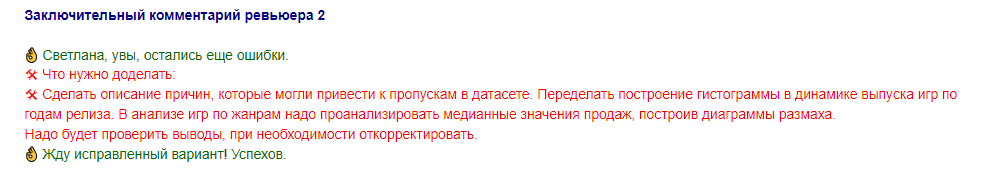

<font color='DarkBlue'><b>Заключительный комментарий ревьюера 3</b></font><br><br>
<font color='DarkGreen'>👌 Светлана! Удалось справиться со всеми подводными камнями в проекте.  Молодец! 😄<br>
Входе выполнения проекта узнали, что не все пропуски просто ошибки сбора данных, а несут свои признаки. Для этого понадобилось за данными датасета увидеть смысл этих данных и бизнес-процессы, которые за ними скрываются. Узнали, что медианы могут дать дополнительную информацию при анализе. Это новые знания и навыки, которые пригодятся в будущем!<br></font>
<font color='DarkGreen'>👌 Теперь, вперед за новыми знаниями и навыками! Удачи! 😉</font>
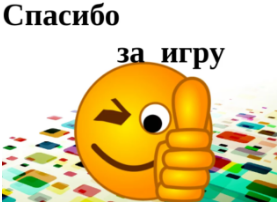